In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load the dataset
df = pd.read_excel('School_data.xlsx')
df1 = pd.read_excel("FLHS_Datasheet.xlsx")
df2 = pd.read_excel("MSS_Datasheet.xlsx")
df2.columns,df1.columns = df.columns, df.columns

data = pd.concat((df,df1, df2), axis = 0)
data = data.iloc[:, 1:]
# data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 449 entries, 0 to 225
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   School's Name  449 non-null    object
 1   Class          449 non-null    object
 2   Gender         449 non-null    object
 3   Age            449 non-null    int64 
 4   Active         449 non-null    int64 
 5   Reflective     449 non-null    int64 
 6   Sensing        449 non-null    int64 
 7   Intuitive      449 non-null    int64 
 8   Visual         449 non-null    int64 
 9   Verbal         449 non-null    int64 
 10  Sequential     449 non-null    int64 
 11  Global         449 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 45.6+ KB


In [6]:
data.describe()

,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,14.403118,0.581292,0.418708,0.616927,0.383073,0.385301,0.614699,0.654788,0.345212
std,2.032128,0.493898,0.493898,0.486678,0.486678,0.487209,0.487209,0.475968,0.475968
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Clearning / Analysis

In [7]:
data['Class'] = data['Class'].str.replace(' ', '')
data['Class'] = data['Class'].str.replace('SSI', 'SS1')
data["School's Name"] = data["School's Name"].str.replace('METHODIST SECONDARY SCHOOL IBIAKU ISSIET, URUAN','METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN')

grouping the dataset according to school

In [8]:
community = data[data["School's Name"] == "Community Secondary Commercial School, Ikot Inyang, Ikot Ekpene"]
full_life = data[data["School's Name"] == "Full Life International Schools (Academy), Airport Road, Uyo"]
methodist = data[data["School's Name"] == "METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN"]


A funtion to plot the features distributions

In [9]:
def plot_feature_distributions(data):
    # Select relevant features for clustering
    features = ['Age', 'Active', 'Reflective', 'Sensing', 'Intuitive ', 'Visual ', 'Verbal', 'Sequential', 'Global']

    # Visualize the distributions of features
    plt.figure(figsize=(12, 8))
    for i, feature in enumerate(features):
        plt.subplot(3, 3, i+1)
        sns.histplot(data[feature])
        plt.title(feature)
    plt.tight_layout()
    plt.show()

A funtion to make multivariate plot of the various feature

In [10]:
def plot_lineplots(data):
    plt.figure(figsize=(16, 10))
    
    # Third Line Plot
    plt.subplot(221)
    ax3 = sns.lineplot(data=data, y='Age', x=data.Class.values, hue='Intuitive ')
    ax3.set_title('Lineplot for Age, Class, and Intuitive Distribution', fontweight='bold', size=14)
    ax3.title.set_position([0.5, 1.05])  # Adjust the position of the title

    # Fourth Line Plot
    plt.subplot(222)
    ax4 = sns.lineplot(data=data, x=data.Class.values, y='Age', hue='Visual ')
    ax4.set_title('Lineplot for Class, Age, and Visual Distribution', fontweight='bold', size=14)
    ax4.title.set_position([0.5, 1.05])  # Adjust the position of the title

    plt.tight_layout()
    plt.show()

ValueError: cannot reindex on an axis with duplicate labels

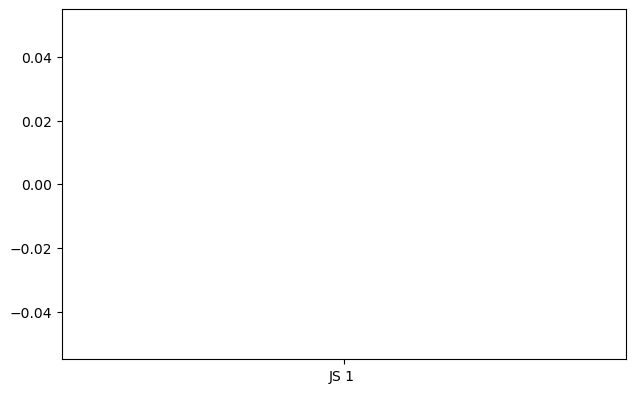

In [18]:
plt.figure(figsize=(16, 10))

# Second Line Plot
plt.subplot(222)
ax2 = sns.lineplot(data=data, x=data.Class.values, y='Age', hue='Gender')
ax2.set_title('Lineplot for Class, Age, and Gender Distribution', fontweight='bold', size=14)
ax2.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Third Line Plot
plt.subplot(223)
ax3 = sns.lineplot(data=data, x='Age', y= data.Class.values, hue='Reflective')
ax3.set_title('Scatterplot for Age, Class, and Reflective Distribution', fontweight='bold', size=14)
ax3.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Fourth Line Plot
plt.subplot(224)
ax4 = sns.lineplot(data=data, x= data.Class.values, y='Age', hue='Sensing')
ax4.set_title('Lineplot for Class, Age, and Sensing Distribution', fontweight='bold', size=14)
ax4.title.set_position([0.5, 1.05])  # Adjust the position of the title

plt.tight_layout()
plt.show()

A funtion to plot age distribution for the each of the schools

In [11]:
def plotAgeDistribution(data):
    bi = [10,15,20,25]
    plt.subplots(1,2,figsize=(15,6))
    plt.subplot(121)
    sns.boxplot(x='Age',data=data,showmeans=True)
    plt.title('Boxplot for Age',fontweight='bold',size=12)
    plt.subplot(122)
    data["Age"].value_counts().plot(kind = 'bar',
                                   title = 'Age distribution');

Community

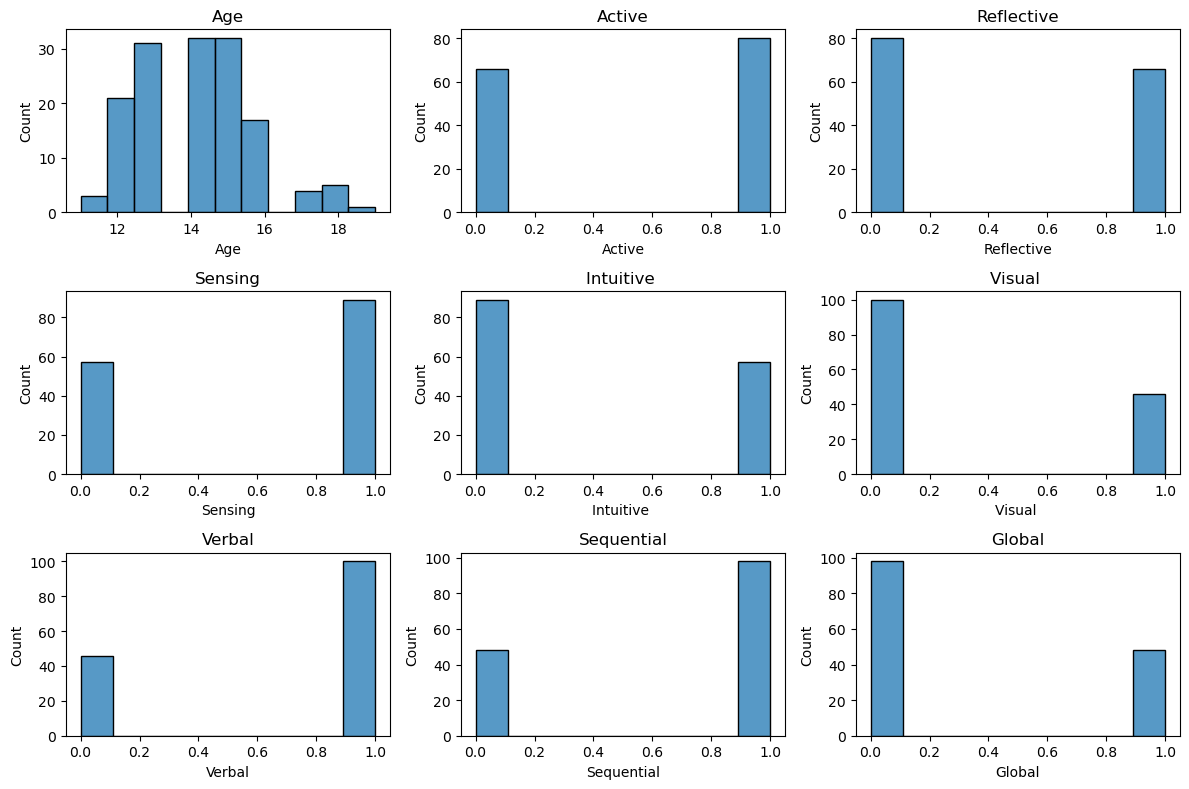

In [12]:
plot_feature_distributions(community)

- 'Community Secondary Commercial School, Ikot Inyang, Ikot Ekpene'

1. Age Distribution: The plot shows a prominent age group among the students, with the highest population falling at 14 and 15 years old.
2. Active vs. Inactive Students: The plot indicates a higher number of active students compared to inactive ones, suggesting a higher level of engagement among the student population.
3. Reflective vs. Non-Reflective Students: The plot highlights a predominant learning style preference among the students, with more students being non-reflective than reflective.
4. Sensing Students: The plot reveals a dominant characteristic among the student population, as there is a higher population of students with a sensing learning style preference.
5. Intuitive Students: The plot suggests that intuition is a relatively less common learning style preference, as there are fewer intuitive students compared to non-intuitive ones.
6. Visual vs. Non-Visual Learners: The plot showcases a prevalent learning style preference within the dataset, with a higher population of students being visual learners.
7. Verbal Students: The plot demonstrates a prominent characteristic among the student population, as there are more students with a preference for verbal learning.
8. Sequential vs. Non-Sequential Learners: The plot illustrates a dominant learning pattern within the student population, with a higher population of students preferring a sequential learning style.
9. Global Learners: The plot indicates that a smaller population of students exhibits a global learning style preference, suggesting it is relatively less common among the student population.


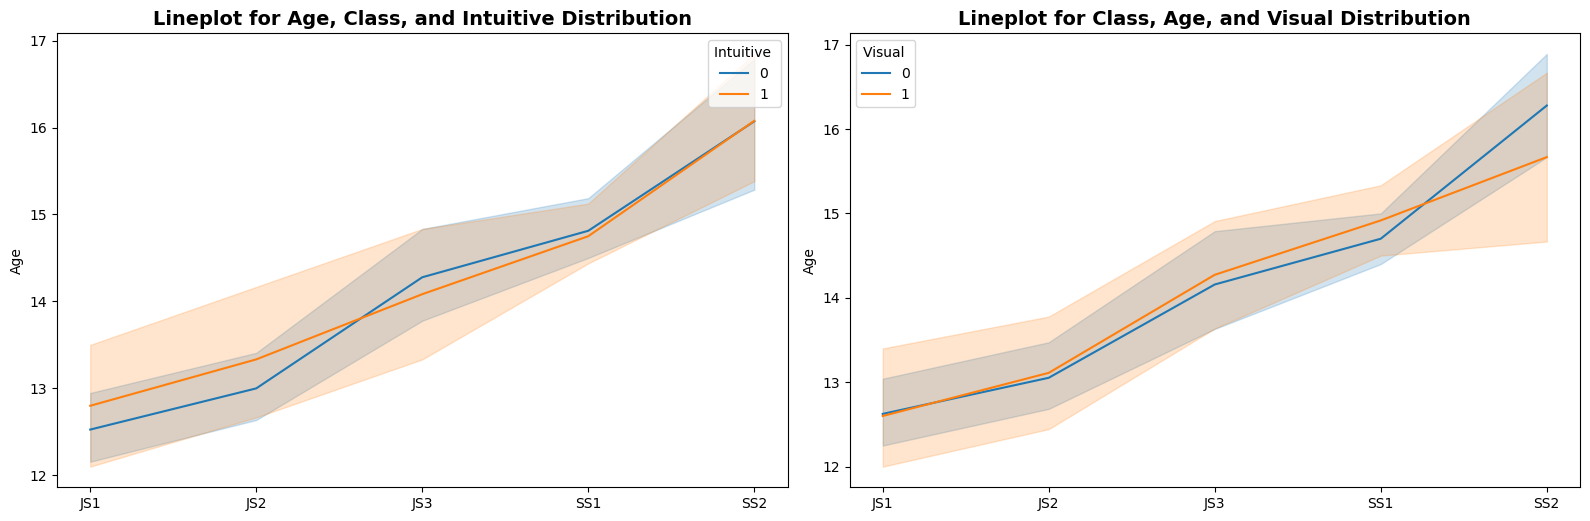

In [11]:
plot_lineplots(community)

- in the above plo, we tends to have a higher number of male students in JS1 and JS2 with a lower age bracket 7- 11years
- From JS3 the populations of the intuitive students tends to be higher than that of the male, while SS2 students tends to have equal distribution of Genders


- For the second plot  the visuals tends to be of lower distribution and then higehr from JS2 to SS2 where it becomes lower again 
-------------
- There is no report from SS3 students in community secondary school

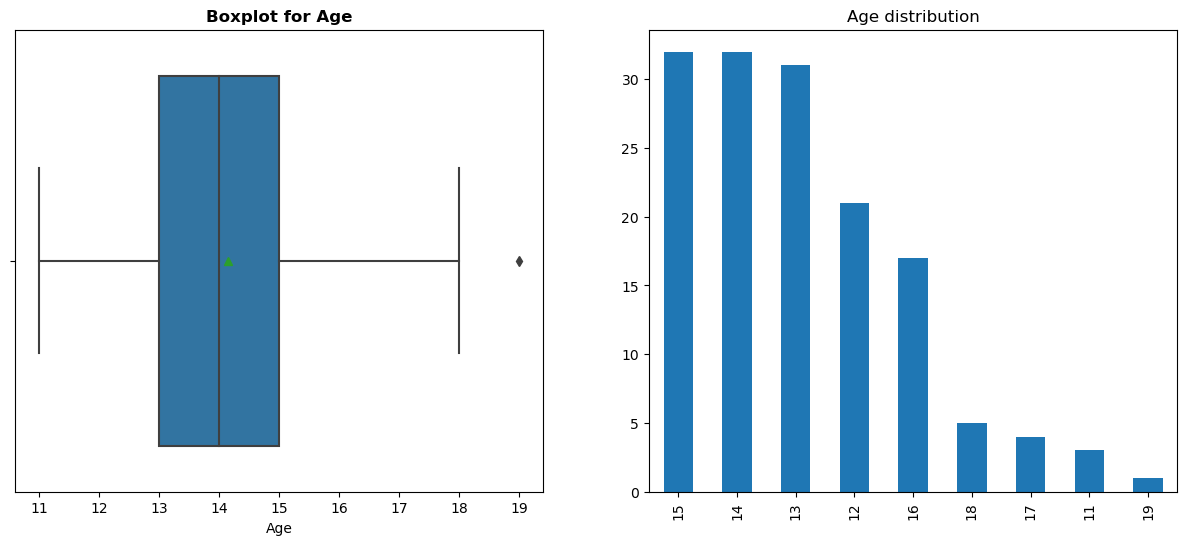

In [68]:
plotAgeDistribution(community)

There is no outliars on the age columns and also in the barchart those that are 15 years of age tends to be of higher population followed by those of 14 and 13 years of age and also those of 11years appears to be of least population followed by those that are 19years of age

Methondist

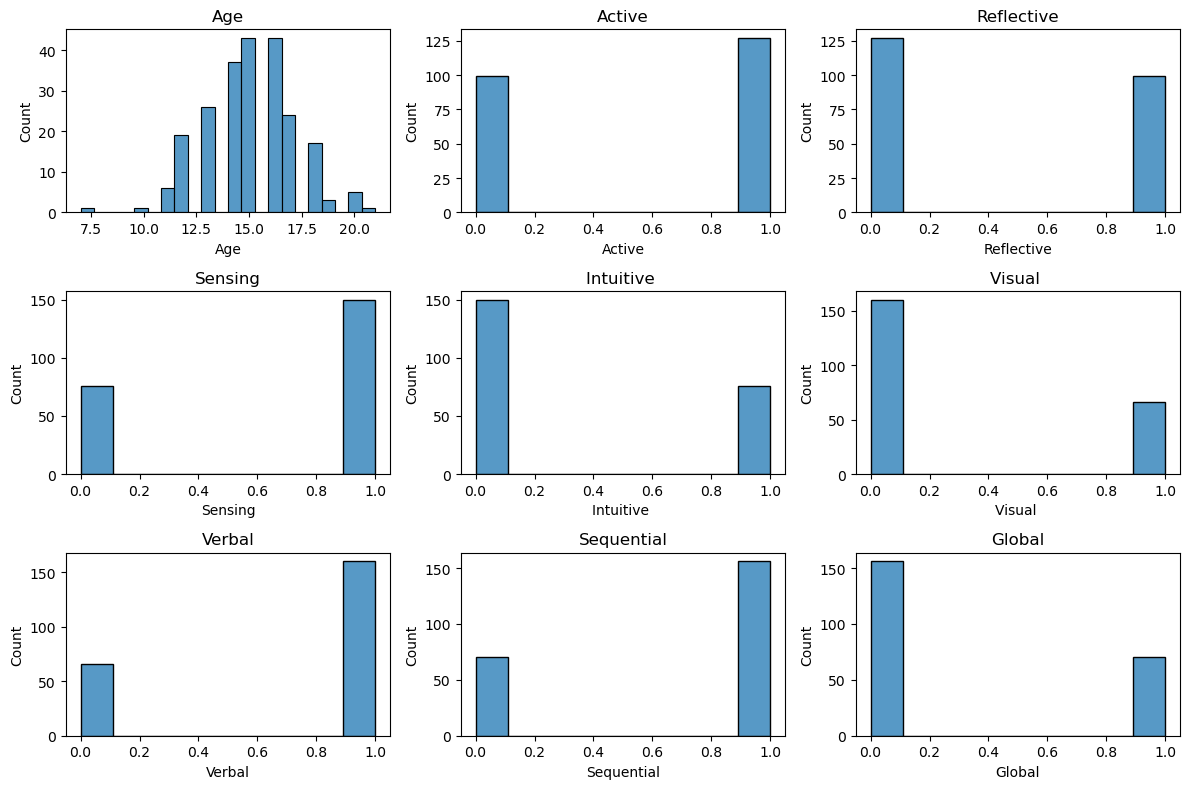

In [12]:
plot_feature_distributions(methodist)

- "METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN"


1. Age Distribution: The plot shows a prominent age group among the students, with the highest population falling at 15 and 16 years old.
2. Active vs. Inactive Students: The plot indicates a higher number of active students compared to inactive ones, suggesting a higher level of engagement among the student population.

3. Reflective vs. Non-Reflective Students: The plot highlights a predominant learning style preference among the students, with more students being non-reflective than reflective.

4. Sensing Students: The plot reveals a dominant characteristic among the student population, as there is a higher population of students with a sensing learning style preference.

5. Intuitive Students: The plot suggests that intuition is a relatively less common learning style preference, as there are fewer intuitive students compared to non-intuitive ones.

6. Visual vs. Non-Visual Learners: The plot showcases a prevalent learning style preference within the dataset, with a lower population of students being visual learners.

7. Verbal Students: The plot demonstrates a prominent characteristic among the student population, as there are more students with a preference for verbal learning.

8. Sequential vs. Non-Sequential Learners: The plot illustrates a dominant learning pattern within the student population, with a higher population of students preferring a sequential learning style.

9. Global Learners: The plot indicates that a smaller population of students exhibits a global learning style preference, suggesting it is relatively less common among the student population.


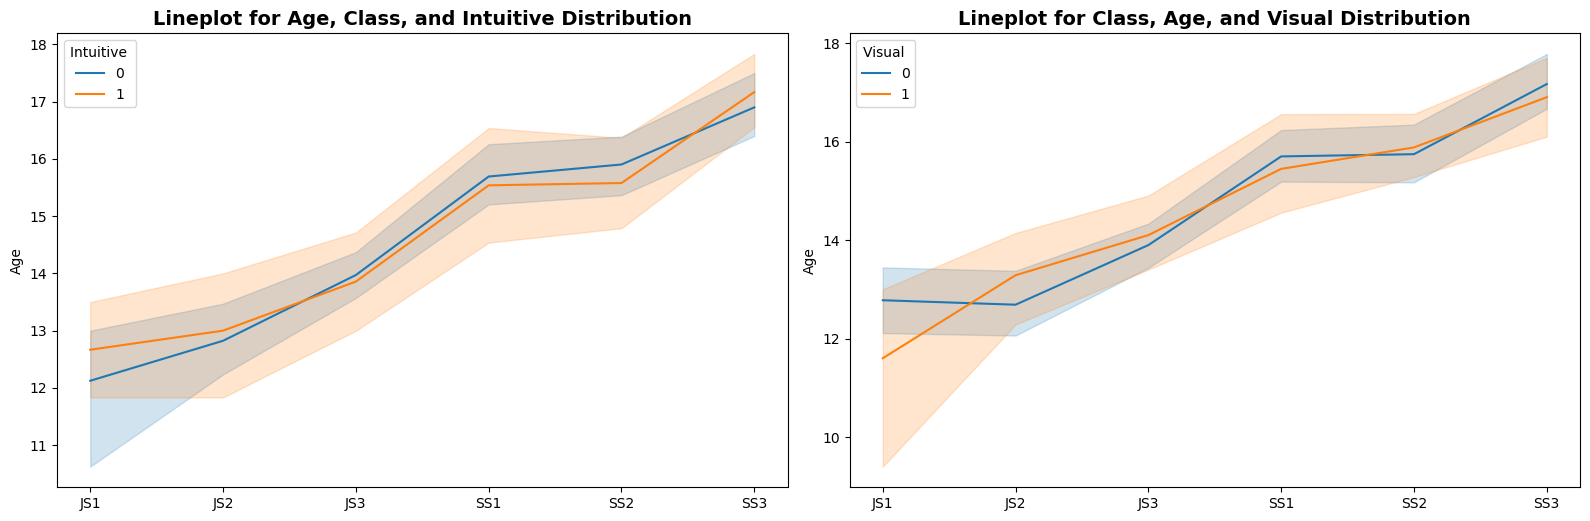

In [13]:
plot_lineplots(methodist)

- The above chart shows that the intuitive students tends to be of higher population in JS1, JS2 and SS3
- The Lineplot for Class. Age and Visual distribution shows that students that are visual tends to be of lower population in JS1, SS1 and SS3

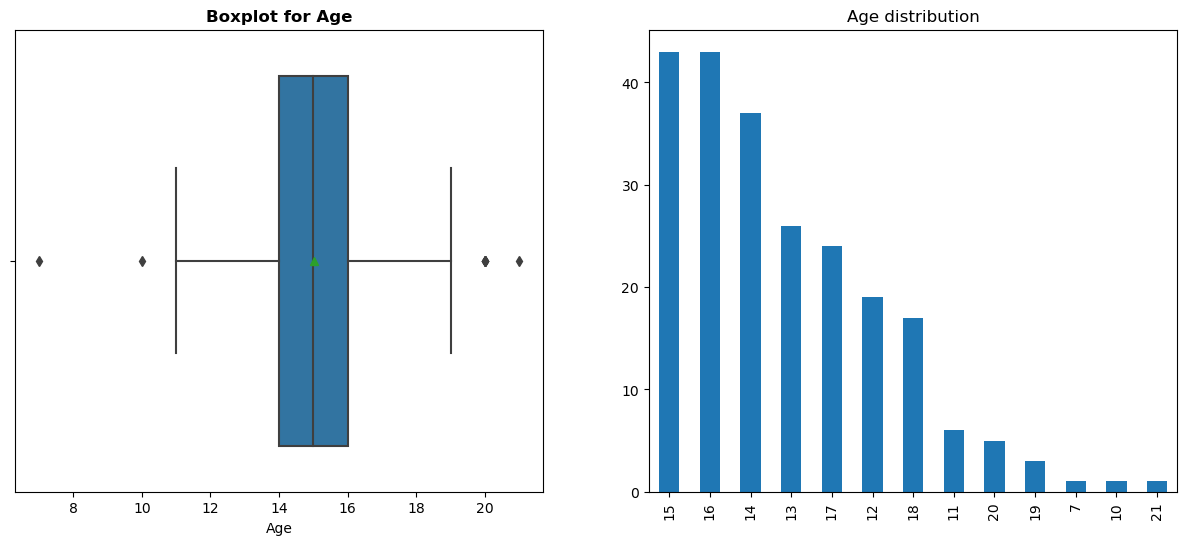

In [69]:
plotAgeDistribution(methodist)

There is no outliars on the age columns and also the those that are 15 years of age tends to be of higher population followed by those of 16 and 14 years of age and also those of 7years appears to be of least population followed by those that are 10years of age

Full_life

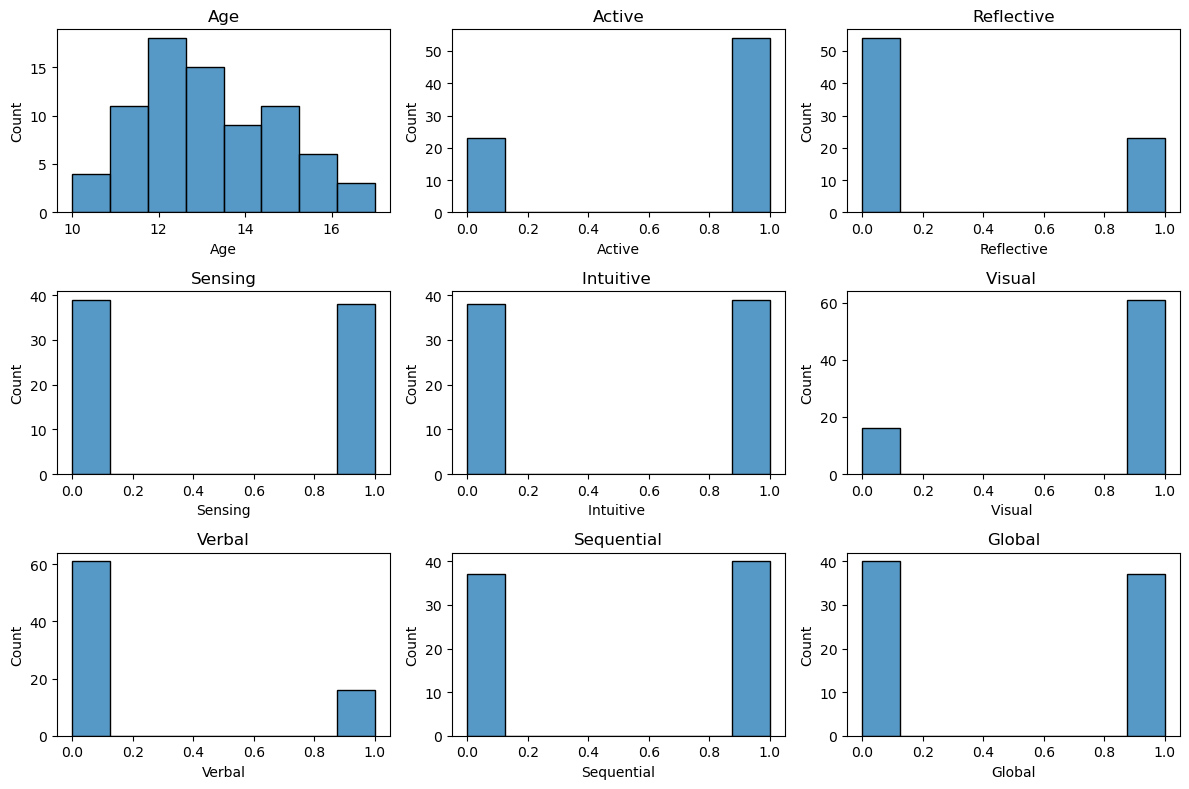

In [14]:
plot_feature_distributions(full_life)

- 'Full Life International Schools (Academy), Airport Road, Uyo'

1. Age Distribution: The plot shows a prominent age group among the students, with the highest population falling at 12 years old.
2. Active vs. Inactive Students: The plot indicates a higher number of active students compared to inactive ones, suggesting a higher level of engagement among the student population.
3. Reflective vs. Non-Reflective Students: The plot highlights a predominant learning style preference among the students, with more students being non-reflective than reflective.
4. Sensing Students: The plot reveals a dominant characteristic among the student population, as there is slightly higher population of students with a sensing learning style preference.
5. Intuitive Students: The plot suggests that intuition is a slightly more common learning style preference, as there are fewer intuitive students compared to non-intuitive ones.
6. Visual vs. Non-Visual Learners: The plot showcases a prevalent learning style preference within the dataset, with a higher population of students being visual learners.
7. Verbal Students: The plot demonstrates a prominent characteristic among the student population, as there are few students with a preference for verbal learning.
8. Sequential vs. Non-Sequential Learners: The plot illustrates a dominant learning pattern within the student population, with a higher population of students preferring a sequential learning style.
9. Global Learners: The plot indicates that a smaller population of students exhibits a global learning style preference, suggesting it is relatively less common among the student population.


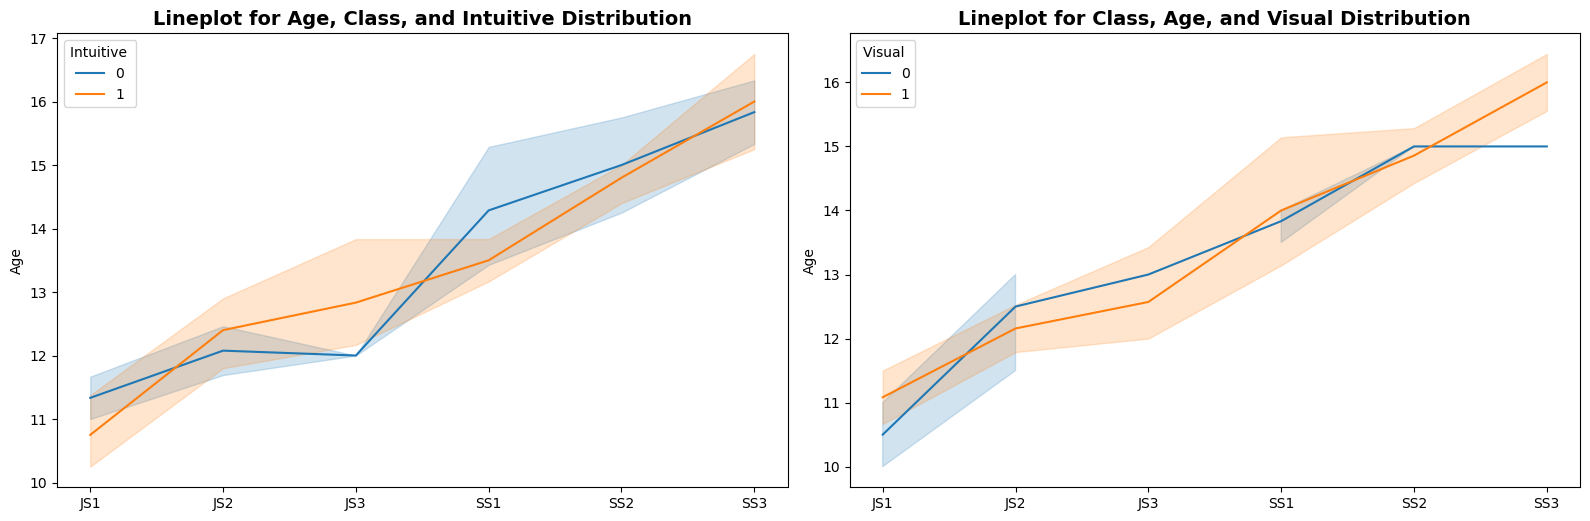

In [15]:
plot_lineplots(full_life)

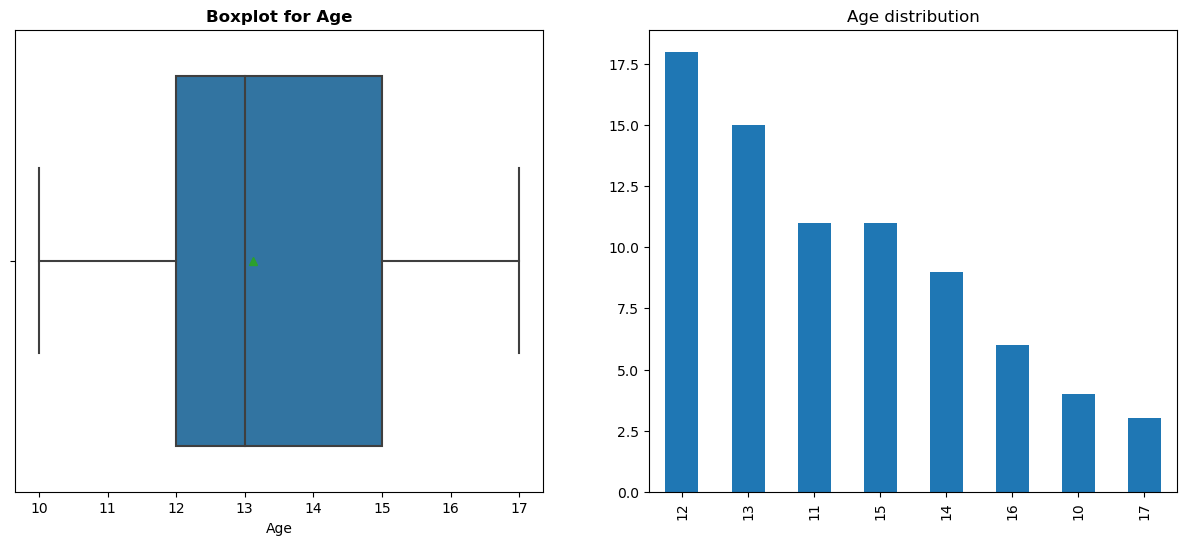

In [70]:
plotAgeDistribution(full_life)

There is no outliars on the age columns and also the those that are 12 years of age tends to be of higher population followed by those of 13 and 15 years respectively and also those of 17years appears to be of least population.

In [16]:
data["School's Name"].unique()

array(['Community Secondary Commercial School, Ikot Inyang, Ikot Ekpene',
       'Full Life International Schools (Academy), Airport Road, Uyo',
       'METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN'], dtype=object)

# Correlations of features for each school

A funtion to print and also plot the correlations of features for each of the schools

In [61]:
def plot_correlation_matrix(data):
    # Visualize the correlation matrix using a heatmap
    plt.figure(figsize=(16, 8))
    sns.heatmap(data.corr(), annot=True, cmap='viridis')
    plt.title('Heatmap of features Correlation Matrix')
    return data.corr()
    plt.show()

Community

,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global
Age,1.000000,0.080982,-0.080982,-0.137518,0.137518,0.067481,-0.067481,0.008171,-0.008171
Active,0.080982,1.000000,-1.000000,0.006569,-0.006569,0.171662,-0.171662,0.008829,-0.008829
Reflective,-0.080982,-1.000000,1.000000,-0.006569,0.006569,-0.171662,0.171662,-0.008829,0.008829
Sensing,-0.137518,0.006569,-0.006569,1.000000,-1.000000,-0.031465,0.031465,0.127328,-0.127328
Intuitive,0.137518,-0.006569,0.006569,-1.000000,1.000000,0.031465,-0.031465,-0.127328,0.127328
Visual,0.067481,0.171662,-0.171662,-0.031465,0.031465,1.000000,-1.000000,-0.121676,0.121676
Verbal,-0.067481,-0.171662,0.171662,0.031465,-0.031465,-1.000000,1.000000,0.121676,-0.121676
Sequential,0.008171,0.008829,-0.008829,0.127328,-0.127328,-0.121676,0.121676,1.000000,-1.000000
Global,-0.008171,-0.008829,0.008829,-0.127328,0.127328,0.121676,-0.121676,-1.000000,1.000000


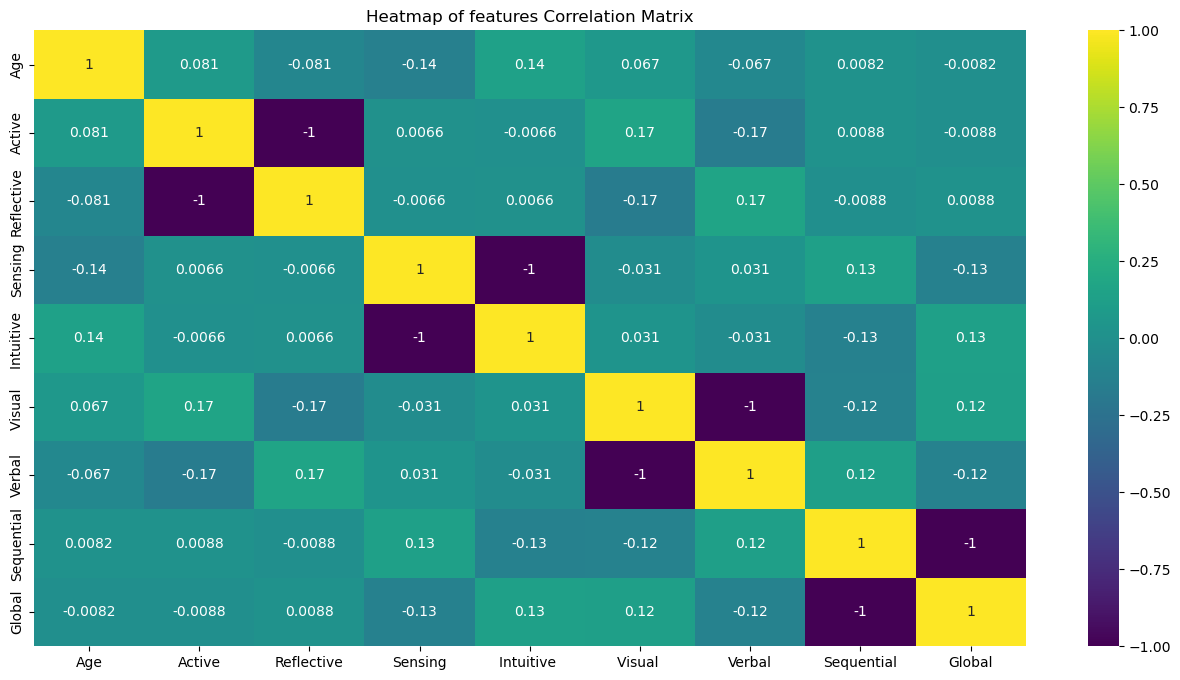

In [62]:
plot_correlation_matrix(community)

The correlation between Intuitive and Global appears to be relatively higher compared to other feature pairs. This suggests that there might be a connection or similarity between a student being active in their learning tends to prefere a Visual learning preference.

Secondly, Reflective shows a moderately positive correlation with verbal learning style. This indicates that students who are more reflective in their learning tend to have a higher preference for verbal learning and are likely to exhibit consistent levels of activeness across different activities.

These correlations highlight potential relationships and dependencies between certain features in the dataset

Methodist

,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global
Age,1.000000,0.054646,-0.054646,-0.063857,0.063857,0.029711,-0.029711,-0.097364,0.097364
Active,0.054646,1.000000,-1.000000,0.221013,-0.221013,0.174787,-0.174787,0.180074,-0.180074
Reflective,-0.054646,-1.000000,1.000000,-0.221013,0.221013,-0.174787,0.174787,-0.180074,0.180074
Sensing,-0.063857,0.221013,-0.221013,1.000000,-1.000000,0.045206,-0.045206,0.232133,-0.232133
Intuitive,0.063857,-0.221013,0.221013,-1.000000,1.000000,-0.045206,0.045206,-0.232133,0.232133
Visual,0.029711,0.174787,-0.174787,0.045206,-0.045206,1.000000,-1.000000,-0.074871,0.074871
Verbal,-0.029711,-0.174787,0.174787,-0.045206,0.045206,-1.000000,1.000000,0.074871,-0.074871
Sequential,-0.097364,0.180074,-0.180074,0.232133,-0.232133,-0.074871,0.074871,1.000000,-1.000000
Global,0.097364,-0.180074,0.180074,-0.232133,0.232133,0.074871,-0.074871,-1.000000,1.000000


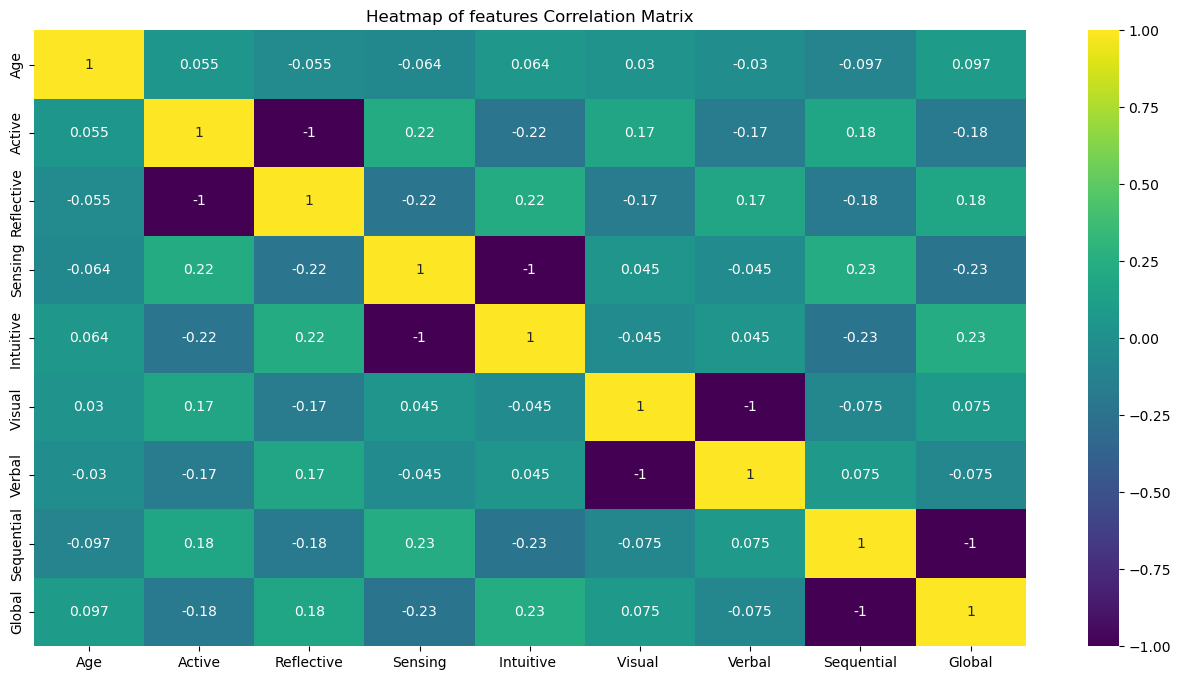

In [63]:
plot_correlation_matrix(methodist)

The correlation between Intuitive, Reflective and Global appears to be relatively higher compared to other feature pairs. This suggests that there might be a connection or similarity between a student being active in their learning tends to prefere a Global learning style.

Secondly, Sensing and Active shows a moderately positive correlation with Sequential learning style. This indicates that students who are more reflective in their learning tend to have a higher preference for Sequential learning and are likely to exhibit consistent levels of activeness across different activities.


Full_life

,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global
Age,1.000000,-0.397055,0.397055,0.079821,-0.079821,-0.037689,0.037689,0.177106,-0.177106
Active,-0.397055,1.000000,-1.000000,0.076656,-0.076656,-0.054496,0.054496,-0.116537,0.116537
Reflective,0.397055,-1.000000,1.000000,-0.076656,0.076656,0.054496,-0.054496,0.116537,-0.116537
Sensing,0.079821,0.076656,-0.076656,1.000000,-1.000000,-0.006652,0.006652,0.273464,-0.273464
Intuitive,-0.079821,-0.076656,0.076656,-1.000000,1.000000,0.006652,-0.006652,-0.273464,0.273464
Visual,-0.037689,-0.054496,0.054496,-0.006652,0.006652,1.000000,-1.000000,-0.044098,0.044098
Verbal,0.037689,0.054496,-0.054496,0.006652,-0.006652,-1.000000,1.000000,0.044098,-0.044098
Sequential,0.177106,-0.116537,0.116537,0.273464,-0.273464,-0.044098,0.044098,1.000000,-1.000000
Global,-0.177106,0.116537,-0.116537,-0.273464,0.273464,0.044098,-0.044098,-1.000000,1.000000


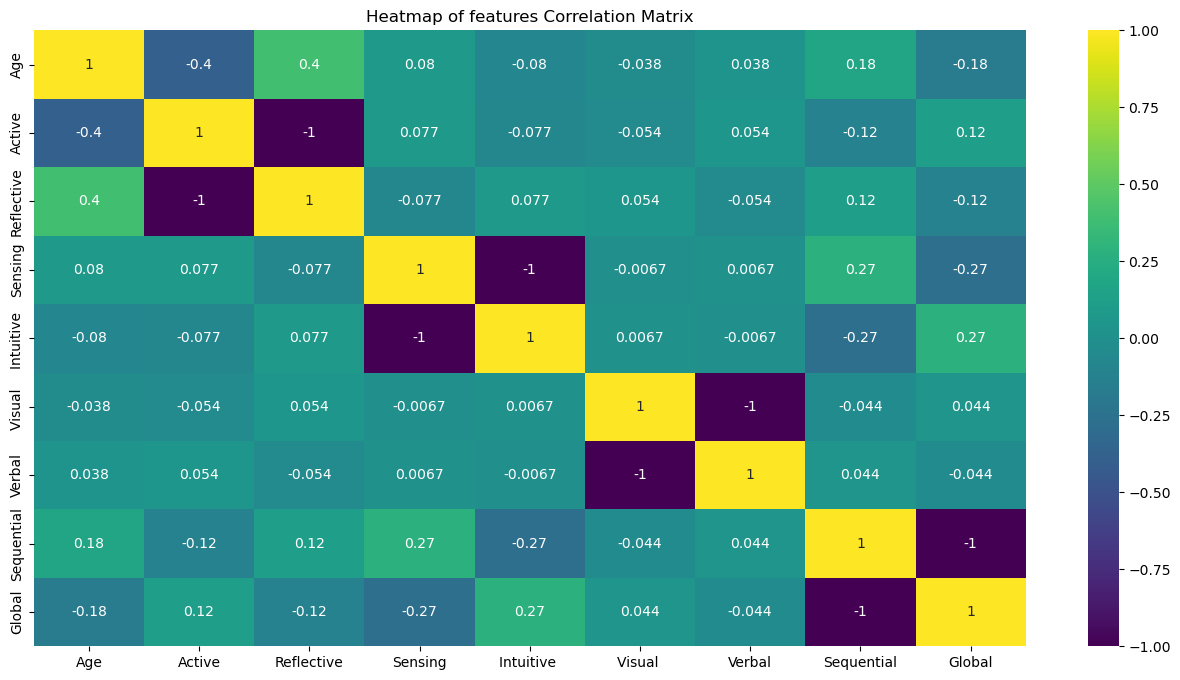

In [64]:
plot_correlation_matrix(full_life)

The correlation between Intuitive and Global appears to be relatively higher compared to other feature pairs. This suggests that there might be a connection or similarity between a student being active in their learning tends to prefere a Global learning preference.

Secondly, Sensing shows a moderately positive correlation with Sequential learning style. This indicates that students who are more sensing in their learning tend to have a higher preference for Sequential learning and are likely to exhibit consistent levels of activeness across different activities.

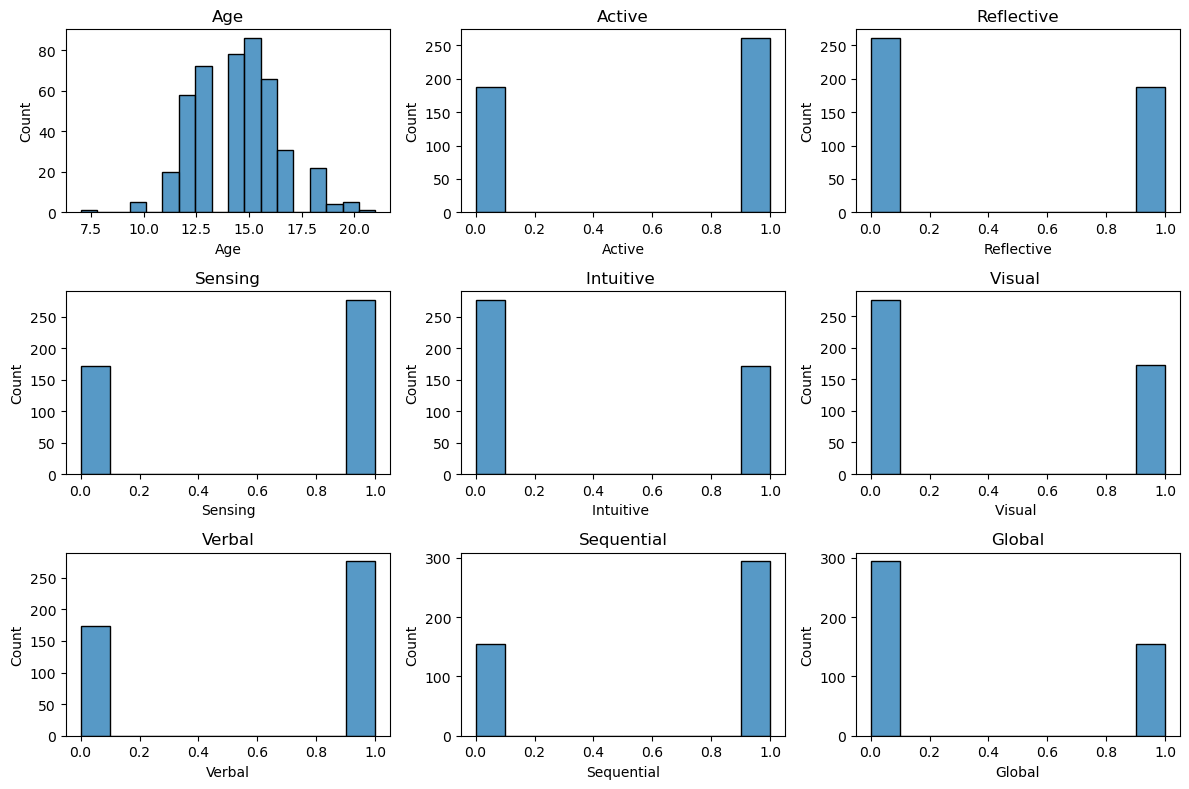

In [72]:
plot_feature_distributions(data)

- Overall Dataset
1. the plot shows that we have the hgighest populations of students that are 15years of age compared to others
2. the second plot shows that we have more active than inactive students
3. the third plot shows that we have more non-reflective students than the reflective ones
4. the fourth plot shews that students who are sensing are more in populations than others which are not
5. the fifth plot shows that we have less intuitive studenst than the intuitive ones
6. the sixth plot shows that we have higher populations of visual than non visuals
7. the seventh plot shows that we have more verbal students than others
8. the eight plot shows the higher populations of sequential than not sequential anf finally the populations of students who are globals tends to be less

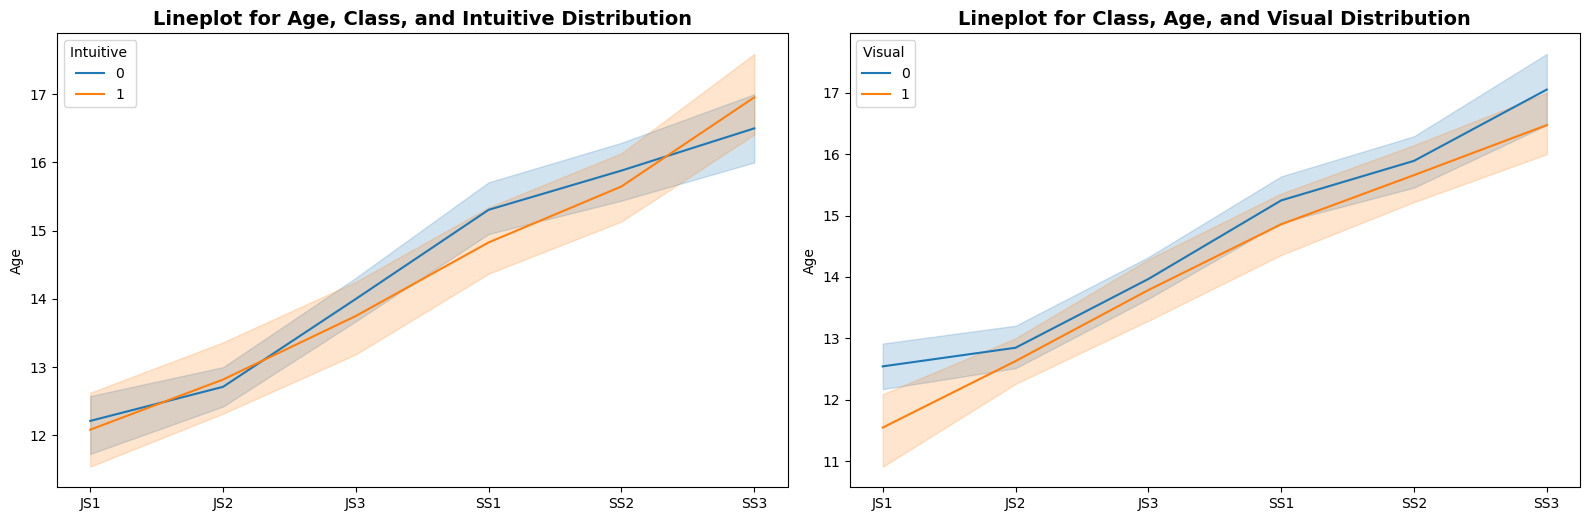

In [74]:
plot_lineplots(data.reset_index())

- the Age class and intuitive plot shows that students tends to be less intuitive in jss1 but more intuitive in js2 between js2 and ss2 students appears to be less intuitive 

- the class, age and gender distribution chart shows that male students all higher in population and also of higher age range on all the classes


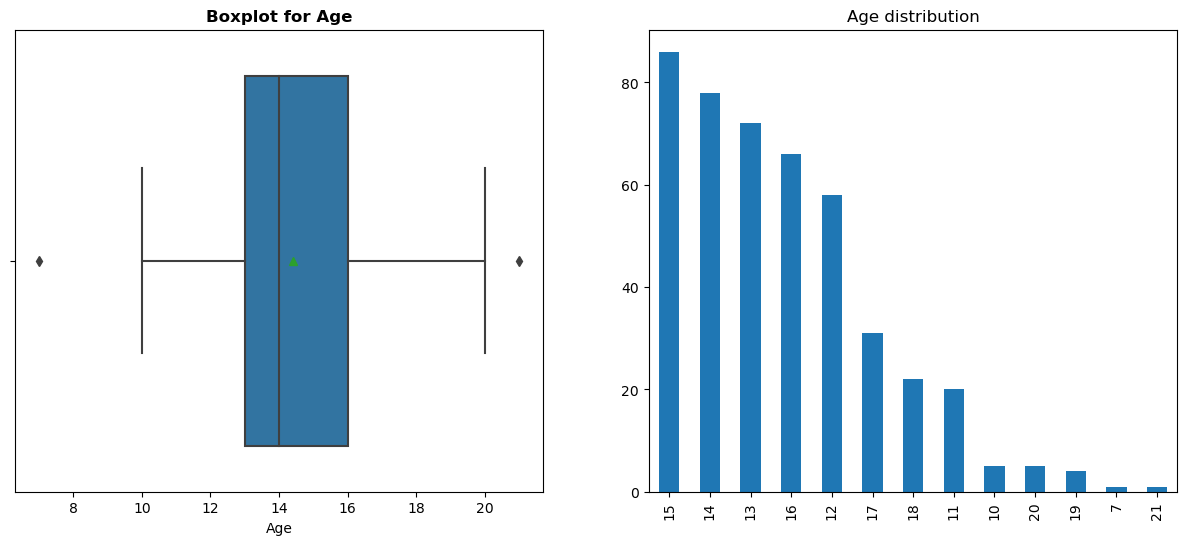

In [71]:
plotAgeDistribution(data)

the is no outliars on the age columns and also the those that are 15 years of age tends to be of higher population followed by those of 14 and 13 years of age and also those of 7years appears to be of least population followed by those that are 21years of age

In [23]:
# Convert categorical variables to numerical representations (if needed)
data_encoded = pd.get_dummies(data, columns=['Gender', "School's Name", 'Class'])
data_encoded.drop(['Class_JS2','Class_JS3','Class_SS1','Class_SS2','Class_SS3',
                  "School's Name_METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",'Gender_F',
                  "School's Name_Full Life International Schools (Academy), Airport Road, Uyo",
                  'Reflective','Sensing','Verbal','Sequential'], axis = 1, inplace = True)

In [24]:
data_encoded

,Age,Active,Intuitive,Visual,Global,Gender_M,"School's Name_Community Secondary Commercial School, Ikot Inyang, Ikot Ekpene",Class_JS1
0,12,0,0,0,0,0,1,1
1,15,1,1,0,0,1,1,1
2,13,0,1,0,1,0,1,1
3,12,1,0,0,0,1,1,1
4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...
221,20,0,1,0,0,1,0,0
222,16,1,0,1,0,1,0,0
223,17,0,1,1,1,1,0,0
224,17,0,1,0,0,0,0,0


In [25]:
data_encoded.columns = ['Age', 'Active',
       'Intuitive ', 'Visual ', 'Global', 'Gender','School_Name','Class']
data_encoded

,Age,Active,Intuitive,Visual,Global,Gender,School_Name,Class
0,12,0,0,0,0,0,1,1
1,15,1,1,0,0,1,1,1
2,13,0,1,0,1,0,1,1
3,12,1,0,0,0,1,1,1
4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...
221,20,0,1,0,0,1,0,0
222,16,1,0,1,0,1,0,0
223,17,0,1,1,1,1,0,0
224,17,0,1,0,0,0,0,0


In [26]:
from sklearn.preprocessing import LabelEncoder 
label_encoder = LabelEncoder()

In [27]:
data_reset = data_encoded.reset_index()  # Reset the index

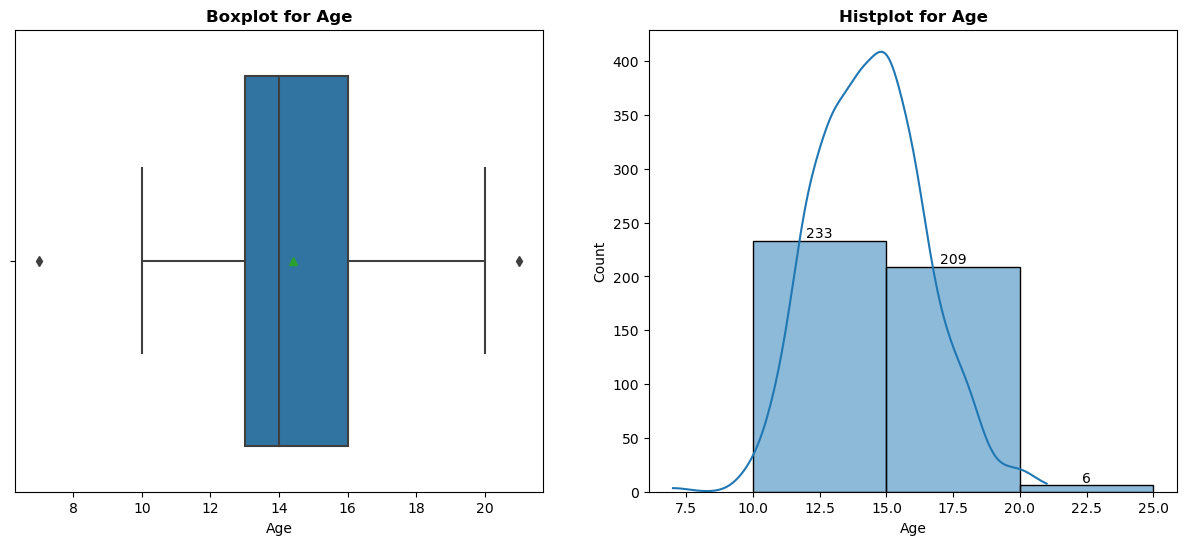

In [28]:
b1 = [10,15,20,25]
plt.subplots(1,2,figsize=(15,6))
plt.subplot(121)
sns.boxplot(x='Age',data=data_reset,showmeans=True)
plt.title('Boxplot for Age',fontweight='bold',size=12)
plt.subplot(122)
ax = sns.histplot(data=data_reset,x='Age',bins=b1,kde=True)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Histplot for Age',fontweight='bold',size=12)
plt.show()



It appears they is no outliars in the age column and also the distribution of  the age is near gausian

-----

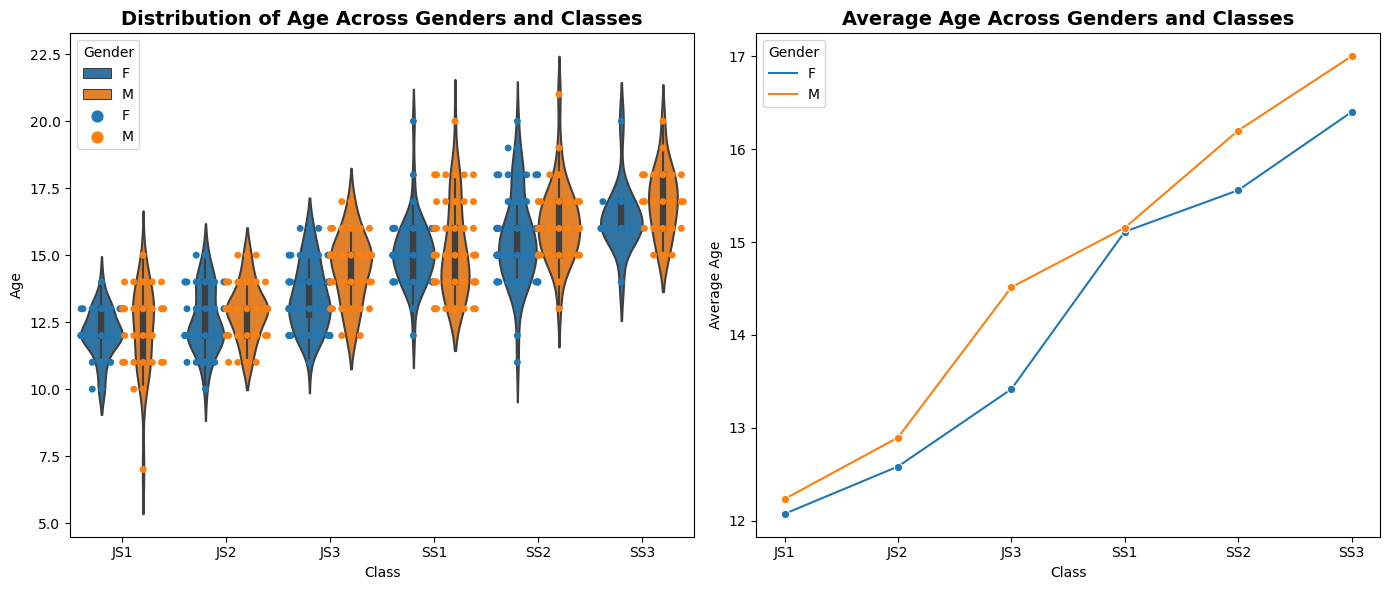

In [29]:
def plot_age_distribution(data):
    # Set up the figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot violinplot and swarmplot
    sns.violinplot(x='Class', y='Age', hue='Gender', data=data, ax=axes[0])
    sns.swarmplot(x='Class', y='Age', hue='Gender', data=data, dodge=True, size=5, ax=axes[0])

    # Set labels and title for violin/swarm plot
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Age')
    axes[0].set_title('Distribution of Age Across Genders and Classes',fontweight='bold',size=14)
    axes[0].legend(title='Gender')

    # Aggregate the data to calculate average age for each gender and class combination
    age_gender_class_avg = data.groupby(['Class', 'Gender'])['Age'].mean().reset_index()

    # Plot lineplot
    sns.lineplot(x='Class', y='Age', hue='Gender', data=age_gender_class_avg, marker='o', ax=axes[1])

    # Set labels and title for line plot
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Average Age')
    axes[1].set_title('Average Age Across Genders and Classes',fontweight='bold',size=14)
    axes[1].legend(title='Gender')

    # Adjust subplot spacing
    plt.tight_layout()

    # Show the plot
    plt.show()
plot_age_distribution(data)

the above shows that in js1 we have higher population of males below the age of 10(ten) and also the violin plot dose'nt cleary show how the populations of each gender in every class but on a closer look on the line chart the male students tends to be of higher populations in every class and also appears to be of higher age range

In [30]:
data_reset

,index,Age,Active,Intuitive,Visual,Global,Gender,School_Name,Class
0,0,12,0,0,0,0,0,1,1
1,1,15,1,1,0,0,1,1,1
2,2,13,0,1,0,1,0,1,1
3,3,12,1,0,0,0,1,1,1
4,4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...
444,221,20,0,1,0,0,1,0,0
445,222,16,1,0,1,0,1,0,0
446,223,17,0,1,1,1,1,0,0
447,224,17,0,1,0,0,0,0,0


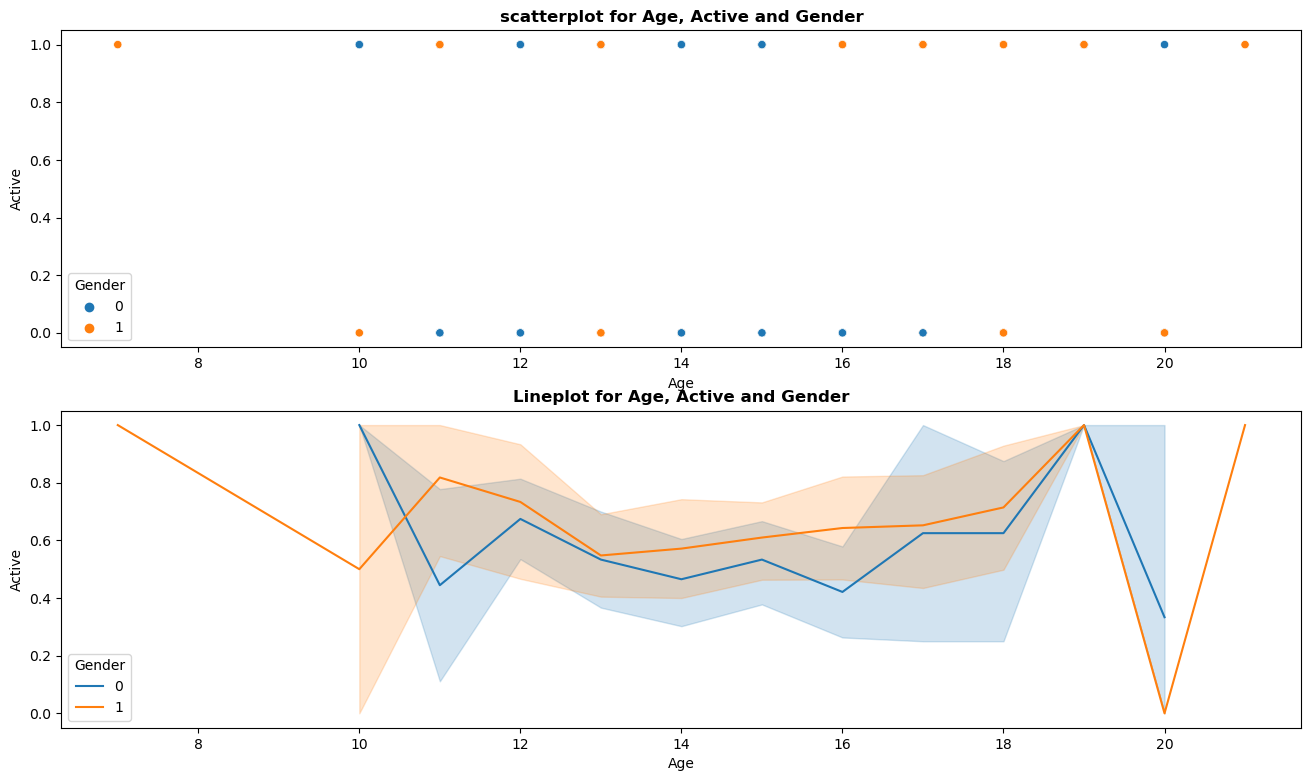

In [31]:
plt.subplots(2,1,figsize=(16,14))
plt.subplot(311)
sns.scatterplot(data=data_reset,x='Age',y='Active',hue='Gender')
plt.title('scatterplot for Age, Active and Gender',fontweight='bold',size=12)
print()
plt.subplot(312)
sns.lineplot(data=data_reset, x='Age', y='Active', hue='Gender')
plt.title('Lineplot for Age, Active and Gender', fontweight='bold', size=12)
plt.show()


In [32]:
data_reset

,index,Age,Active,Intuitive,Visual,Global,Gender,School_Name,Class
0,0,12,0,0,0,0,0,1,1
1,1,15,1,1,0,0,1,1,1
2,2,13,0,1,0,1,0,1,1
3,3,12,1,0,0,0,1,1,1
4,4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...
444,221,20,0,1,0,0,1,0,0
445,222,16,1,0,1,0,1,0,0
446,223,17,0,1,1,1,1,0,0
447,224,17,0,1,0,0,0,0,0


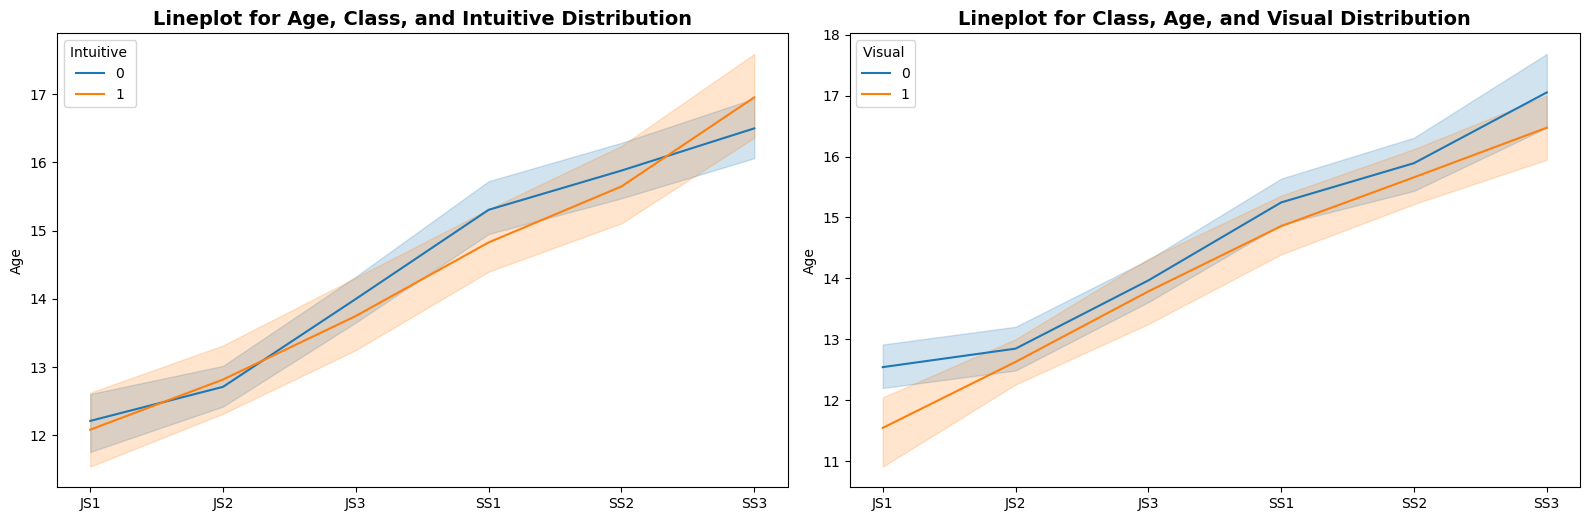

In [33]:
plt.figure(figsize=(16, 10))

# Third Line Plot
plt.subplot(221)
ax3 = sns.lineplot(data=data_reset, y='Age', x=data.Class.values, hue='Intuitive ')
ax3.set_title('Lineplot for Age, Class, and Intuitive Distribution', fontweight='bold', size=14)
ax3.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Fourth Line Plot
plt.subplot(222)
ax4 = sns.lineplot(data=data_reset, x=data.Class.values, y='Age', hue='Visual ')
ax4.set_title('Lineplot for Class, Age, and Visual Distribution', fontweight='bold', size=14)
ax4.title.set_position([0.5, 1.05])  # Adjust the position of the title

plt.tight_layout()
plt.show()

- the Age class and intuitive plot shows that students tends to be less intuitive in jss1 but more intuitive in js2 between js2 and ss2 students appears to be less intuitive 

- the class, age and gender distribution chart shows that male students all higher in population and also of higher age range on all the classes


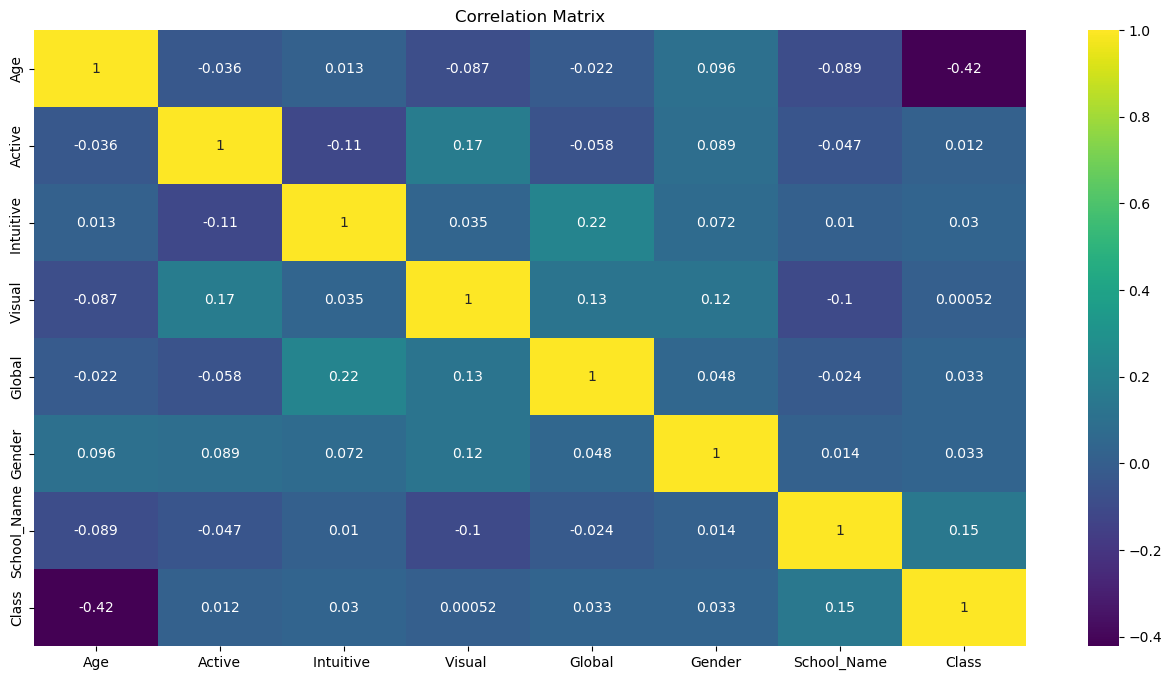

In [34]:
# Calculate the correlation matrix
correlation_matrix = data_reset.iloc[:,1:].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()


the above chart shows the correlations of each each features, the correlations of each features to the other appears relatively low, though intuitive and active tends to be of higher correlation to global and active when compared to others

In [35]:
data_reset

,index,Age,Active,Intuitive,Visual,Global,Gender,School_Name,Class
0,0,12,0,0,0,0,0,1,1
1,1,15,1,1,0,0,1,1,1
2,2,13,0,1,0,1,0,1,1
3,3,12,1,0,0,0,1,1,1
4,4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...
444,221,20,0,1,0,0,1,0,0
445,222,16,1,0,1,0,1,0,0
446,223,17,0,1,1,1,1,0,0
447,224,17,0,1,0,0,0,0,0


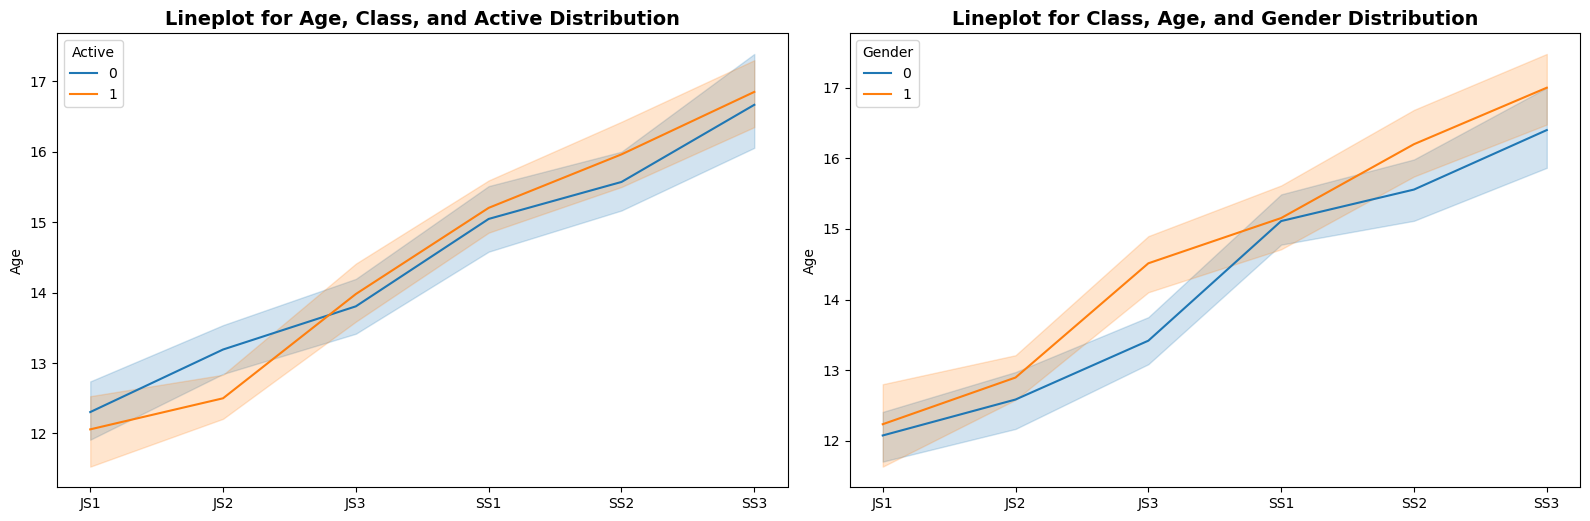

In [36]:
plt.figure(figsize=(16, 10))

# First Line Plot
plt.subplot(221)
ax1 = sns.lineplot(data=data_reset, y='Age', x=data.Class.values, hue='Active')
ax1.set_title('Lineplot for Age, Class, and Active Distribution', fontweight='bold', size=14)
ax1.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Second Line Plot
plt.subplot(222)
ax2 = sns.lineplot(data=data_reset, x=data.Class.values, y='Age', hue='Gender')
ax2.set_title('Lineplot for Class, Age, and Gender Distribution', fontweight='bold', size=14)
ax2.title.set_position([0.5, 1.05])  # Adjust the position of the title



plt.tight_layout()
plt.show()


- the Age class and active plot shows that students tends to be less active between jss1 nad js3 but more active between js3 to ss3

- the class, age and gender distribution chart shows that male students all higher in population and also of higher age range on all the classes


# Data Preprocessing And Modeling

In [37]:
data_reset

,index,Age,Active,Intuitive,Visual,Global,Gender,School_Name,Class
0,0,12,0,0,0,0,0,1,1
1,1,15,1,1,0,0,1,1,1
2,2,13,0,1,0,1,0,1,1
3,3,12,1,0,0,0,1,1,1
4,4,13,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...
444,221,20,0,1,0,0,1,0,0
445,222,16,1,0,1,0,1,0,0
446,223,17,0,1,1,1,1,0,0
447,224,17,0,1,0,0,0,0,0


In [38]:
X = data_reset.iloc[:, 2:]

# Step 4: Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means

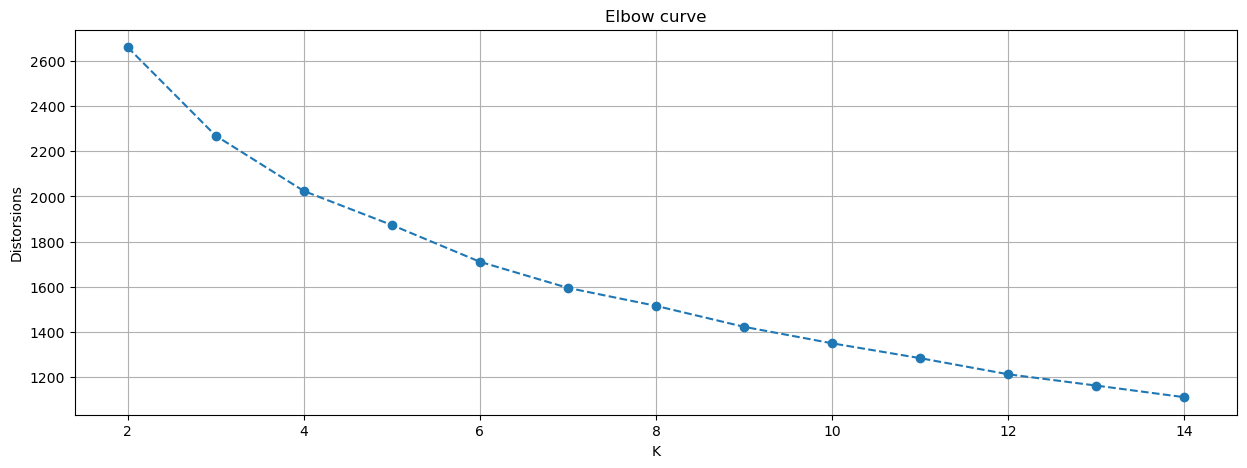

In [39]:
#finding optimum k values
distorsions = []
for k in range(2, 15):
     kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10)
     kmeans.fit(X_scaled)
     distorsions.append(kmeans.inertia_)
fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 15), distorsions,'o--')
plt.grid(True)
plt.xlabel('K')
plt.ylabel('Distorsions')
plt.title('Elbow curve');

In [40]:
clusters_range = np.arange(2,15)
for cluster in clusters_range:
    kmeans = KMeans(n_clusters=cluster,init='k-means++',max_iter=300,n_init=10)
    kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_, metric='euclidean')
    print(f'for cluster: {cluster} --> Silhouetter Score: %.3f' % score)

for cluster: 2 --> Silhouetter Score: 0.174
for cluster: 3 --> Silhouetter Score: 0.187
for cluster: 4 --> Silhouetter Score: 0.187
for cluster: 5 --> Silhouetter Score: 0.203
for cluster: 6 --> Silhouetter Score: 0.212
for cluster: 7 --> Silhouetter Score: 0.217
for cluster: 8 --> Silhouetter Score: 0.238
for cluster: 9 --> Silhouetter Score: 0.249
for cluster: 10 --> Silhouetter Score: 0.267
for cluster: 11 --> Silhouetter Score: 0.276
for cluster: 12 --> Silhouetter Score: 0.292
for cluster: 13 --> Silhouetter Score: 0.316
for cluster: 14 --> Silhouetter Score: 0.332


In [41]:
#model building
model = KMeans(n_clusters=5)
model.fit(X_scaled)

KMeans(n_clusters=5)

In [42]:
labels = model.fit_predict(X_scaled)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 0, 1, 1, 4, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 4, 4, 0, 0, 0, 1, 4, 1, 0,
       4, 1, 0, 0, 1, 1, 1, 0, 1, 4, 4, 1, 0, 1, 0, 0, 4, 4, 0, 0, 0, 0,
       4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 4, 1, 0, 4,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 4, 1, 0, 0, 1, 1, 1,
       1, 1, 4, 1, 1, 1, 1, 1, 4, 1, 1, 4, 0, 4, 1, 1, 1, 1, 4, 4, 1, 0,
       0, 0, 1, 4, 4, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,

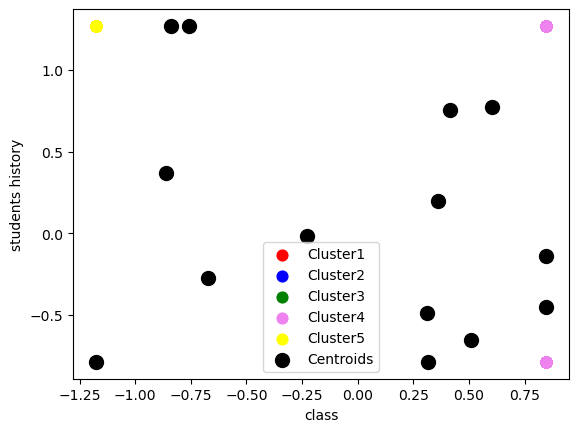

In [43]:
plt.scatter(X_scaled[labels == 0, 0], X_scaled[labels == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X_scaled[labels == 1, 0], X_scaled[labels == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X_scaled[labels == 2, 0], X_scaled[labels == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(X_scaled[labels == 3, 0], X_scaled[labels == 3, 1], s = 60, c = 'violet', label = 'Cluster4')
plt.scatter(X_scaled[labels == 4, 0], X_scaled[labels == 4, 1], s = 60, c = 'yellow', label = 'Cluster5') 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')
plt.xlabel('class')
plt.ylabel('students history')
plt.legend() 

plt.show()

In [44]:
import scipy.cluster.hierarchy as sch

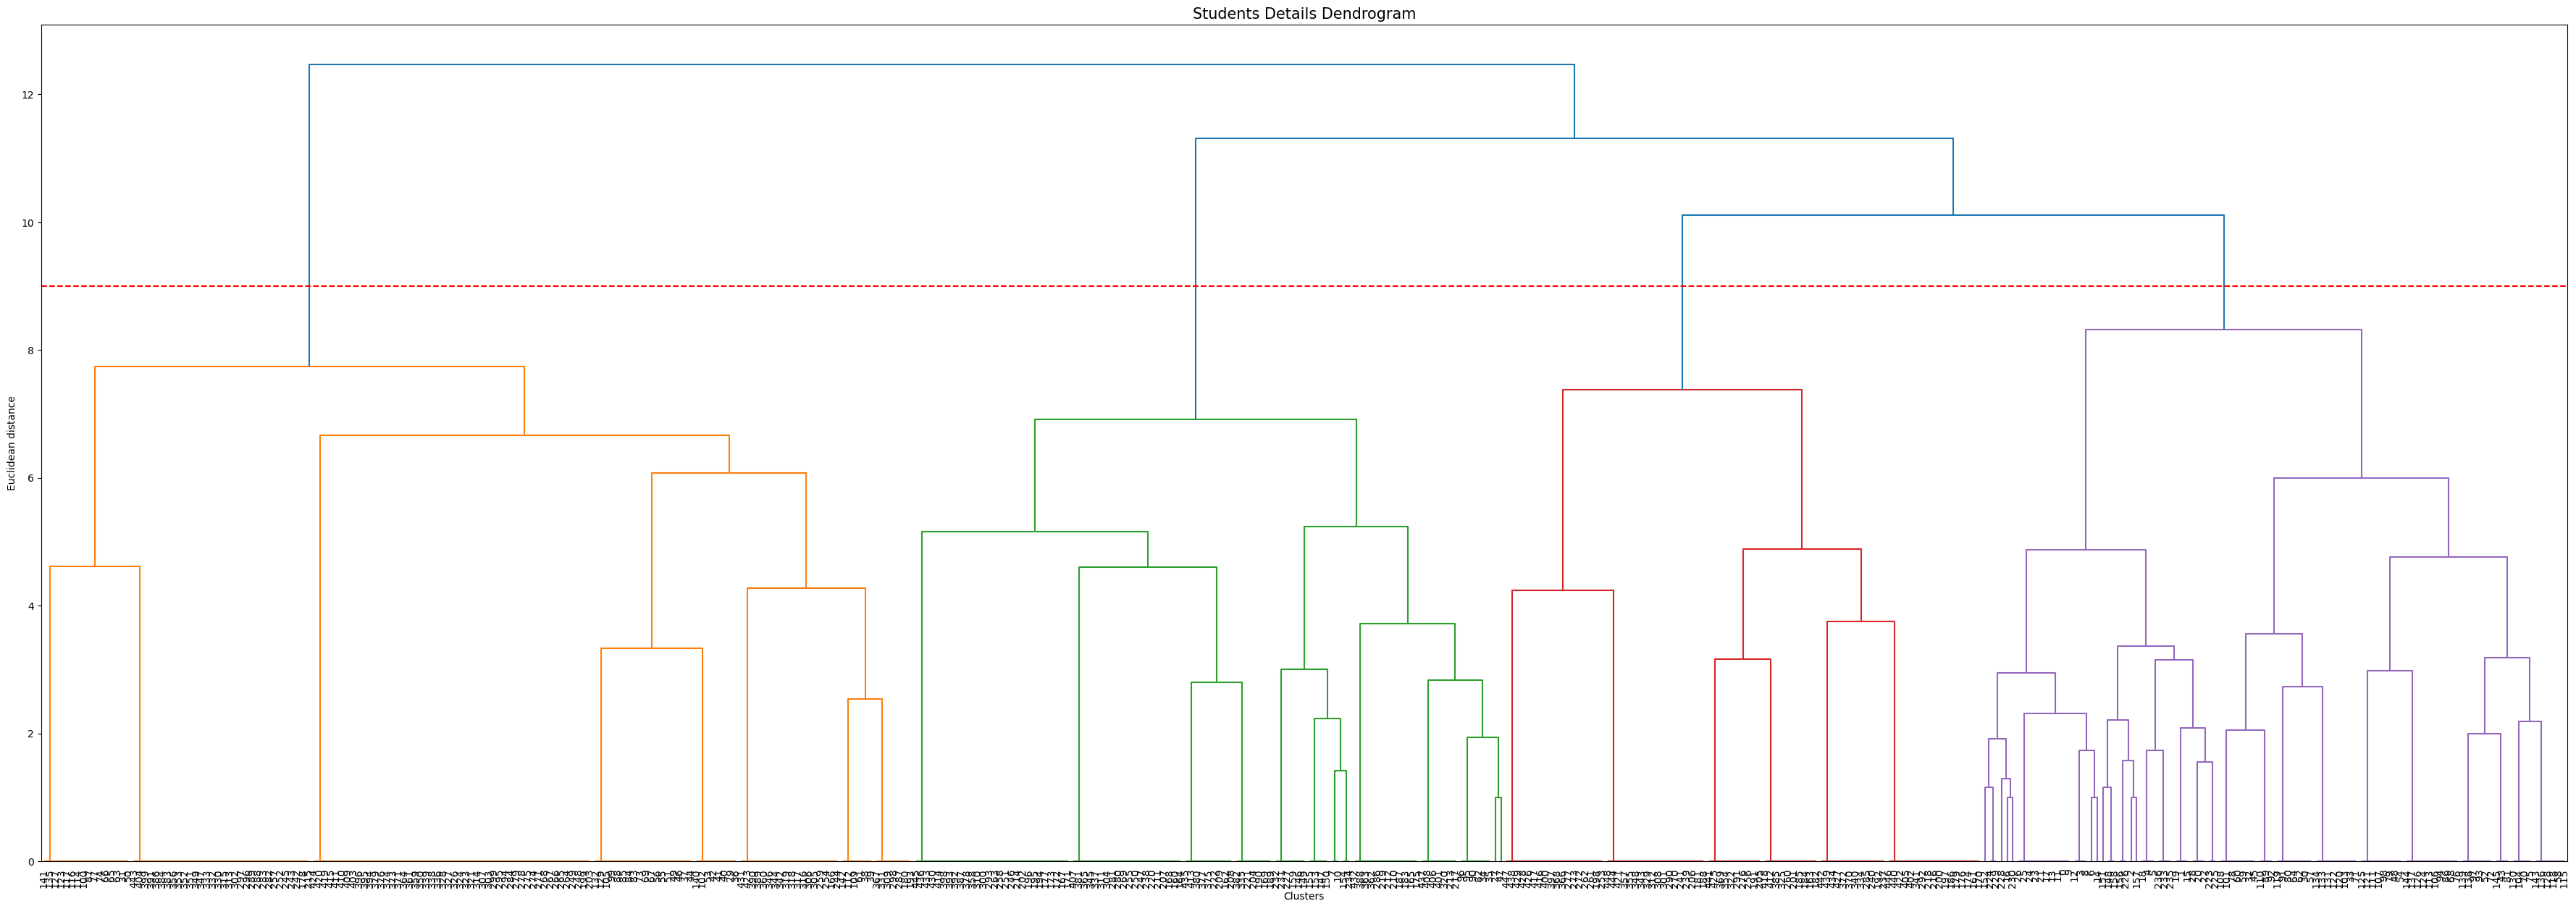

In [45]:
#plotting dendogram
plt.figure(figsize=(45, 15))
dendrogrm = sch.dendrogram(sch.linkage(data_reset.iloc[:,3:], method = 'ward'))
plt.axhline(y=9.0, color='r', linestyle='--')
ax = plt.gca()
ax.tick_params(axis='x', which='major', labelsize=10)
plt.title('Students Details Dendrogram',fontsize=15)
plt.xlabel('Clusters',fontsize=10)
plt.xticks(rotation=90)
plt.ylabel('Euclidean distance', fontsize=10)
plt.show()

# DBscan

In [46]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

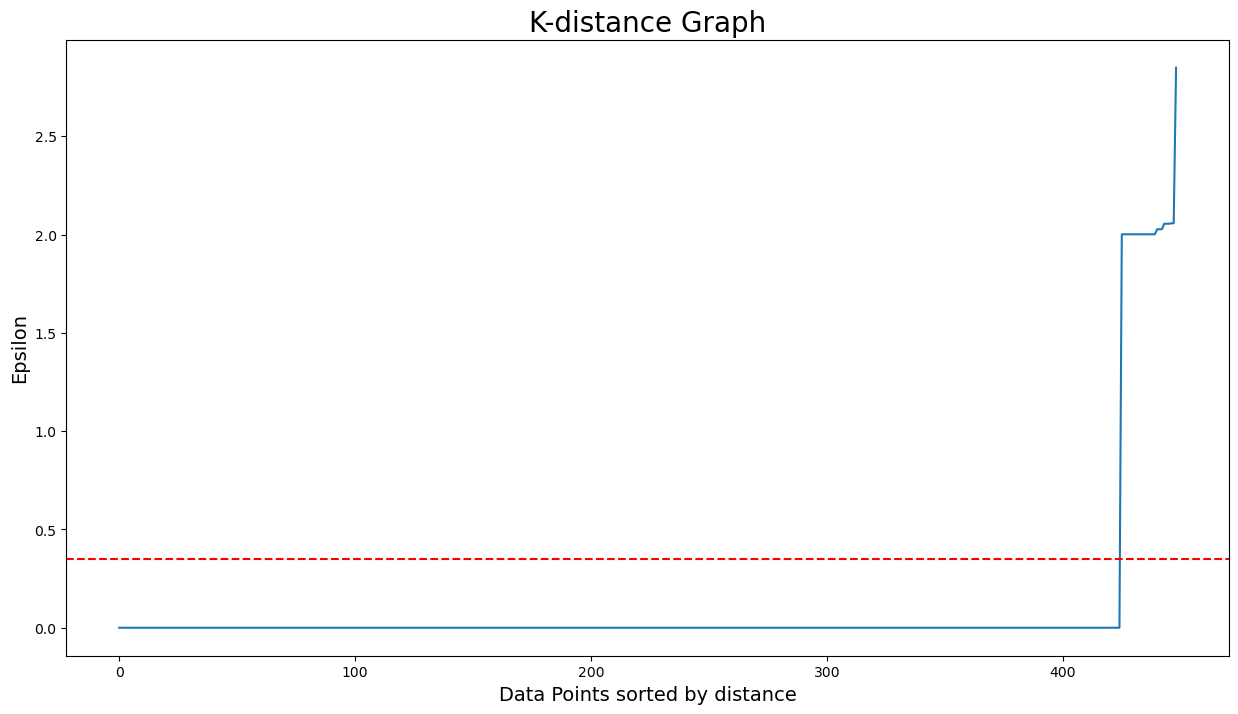

In [47]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(15,8))
plt.plot(distances)
plt.axhline(y=0.35, color='r', linestyle='--')
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

In [48]:
# # using hyper parameter calculating no of min_samples
# eps=0.45
# for min_samples in range(0,25):
#     model=DBSCAN(eps=eps,min_samples=min_samples)
#     cluster_labels = model.fit_predict(X_scaled)
#     x= cluster_labels +2
#     y = np.bincount(x)
#     ii = np.nonzero(y)[0]
#     results = list(zip(ii,y[ii]) )
#     print('eps=',eps,'| min_samples= ', min_samples, '| obtained clustering: ', results)
#     print()

In [49]:
model=DBSCAN(eps=0.45,min_samples=8)
model.fit(X_scaled)

DBSCAN(eps=0.45, min_samples=8)

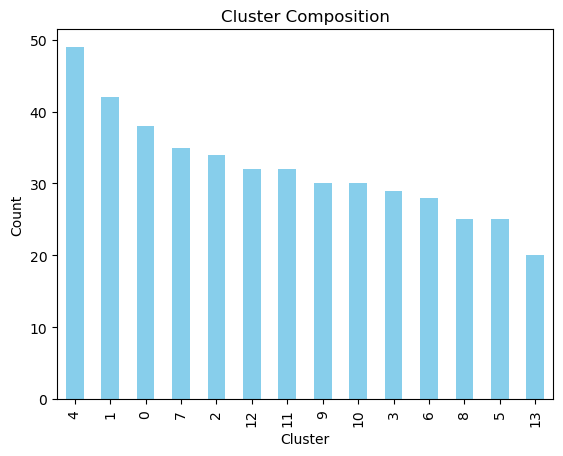

In [50]:
# Get the cluster labels for each student
cluster_labels = kmeans.labels_

# Analyze the cluster composition
cluster_counts = pd.Series(cluster_labels).value_counts()
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Composition')
plt.show()

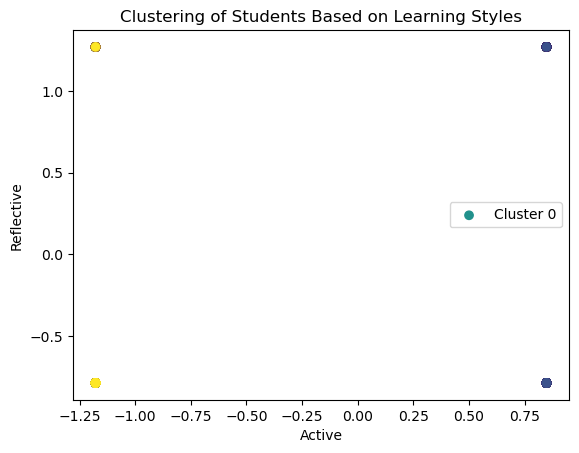

In [51]:
# Scatter plot of the clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel('Active')
plt.ylabel('Reflective')
plt.title('Clustering of Students Based on Learning Styles')

# Add legend
unique_clusters = np.unique(labels)
legend_labels = [f'Cluster {cluster}' for cluster in unique_clusters]
plt.legend(legend_labels)

plt.show()

# Apply dimensionality reduction using PCA

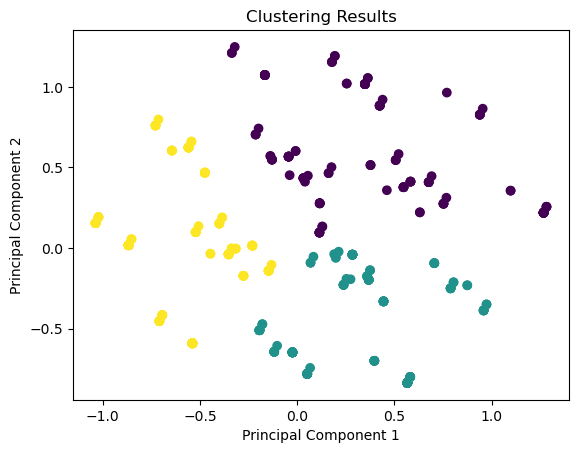

In [52]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(X)

# Perform clustering using K-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_pca)

# Visualize the clusters
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustering Results')
plt.show()

In [53]:
# Funtion To Visualize Models Clustering
def plot(labels, name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=gmm_labels, palette='viridis')
    plt.title(f'{name} Models Clustering')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

In [54]:
def visualize_clusters(data, labels, n_clusters):
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('Clustering Results')
    plt.show()

K-means - Silhouette Score: 0.44078870323443864


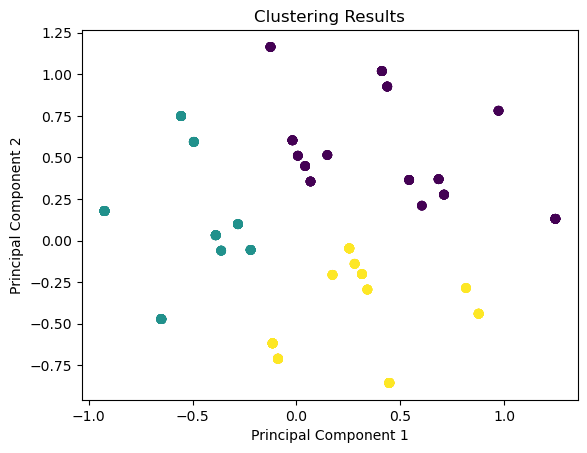

DBSCAN - Silhouette Score: 0.8853581953596681


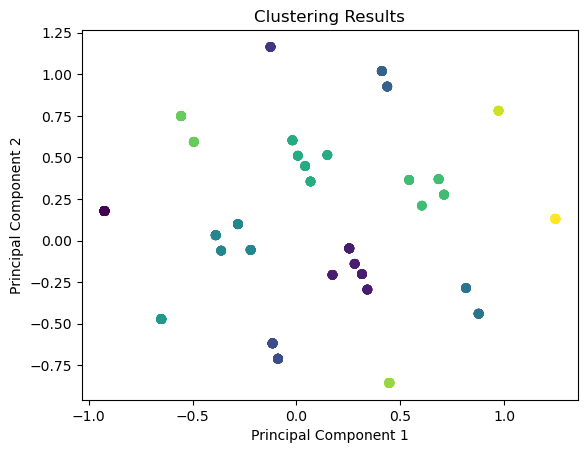

Agg. Hierarchical - Silhouette Score: 0.40472437003934303


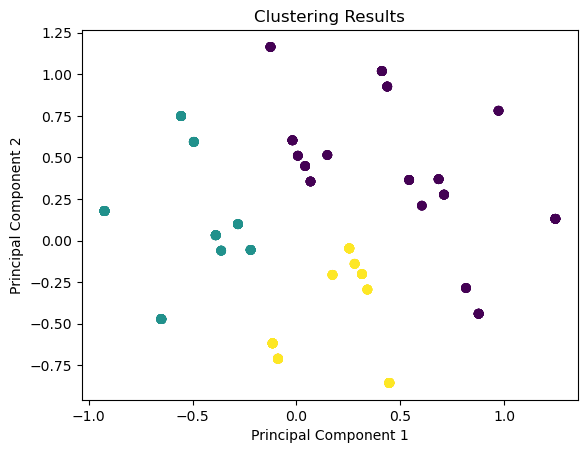

GMM - Silhouette Score: 0.3735970663032283


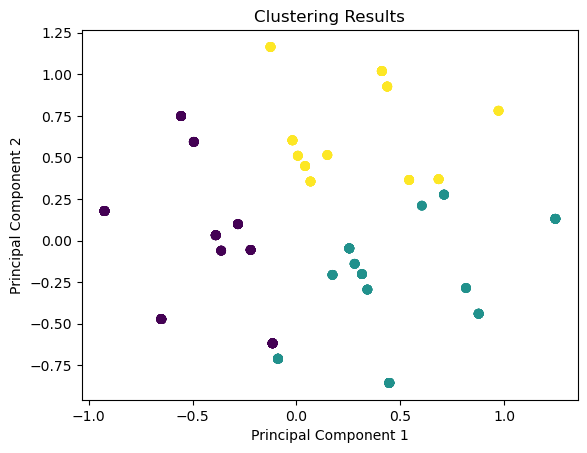

In [55]:
# Experimenting wiht different models 
models = {
    'K-means': KMeans(n_clusters=3, random_state=42),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=5),
    'Agg. Hierarchical': AgglomerativeClustering(n_clusters=3),
    'GMM': GaussianMixture(n_components=3, random_state=42)
}

for model_name, model in models.items():
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(X.iloc[:, :-2])
    if model_name != 'GMM':
        labels = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, labels)
        print(f"{model_name} - Silhouette Score: {silhouette_avg}")
        visualize_clusters(data_pca, labels, len(np.unique(labels)))
    else:
        label = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, label)
        print(f"{model_name} - Silhouette Score: {silhouette_avg}")
        visualize_clusters(data_pca, label, len(np.unique(label)))

K-means - Silhouette Score: 0.44078870323443864
K-means - Davies-Bouldin Score: 0.8453815487678257


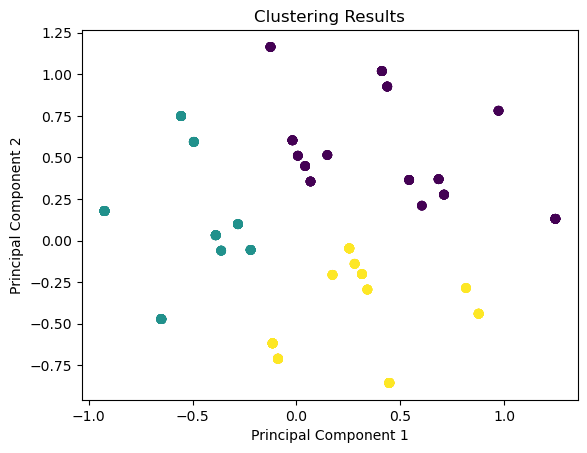

DBSCAN - Silhouette Score: 0.8853581953596681
DBSCAN - Davies-Bouldin Score: 0.21991596365474833


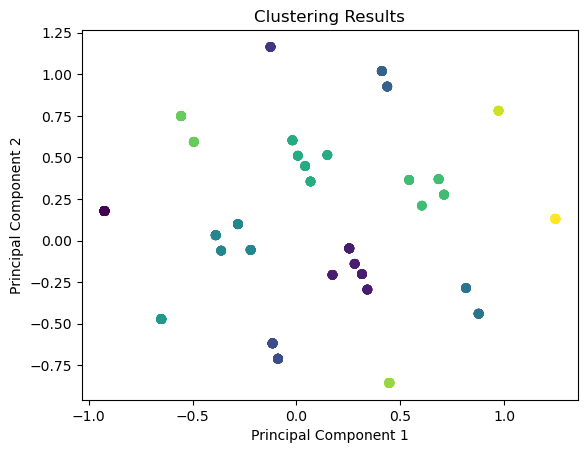

Agg. Hierarchical - Silhouette Score: 0.40472437003934303
Agg. Hierarchical - Davies-Bouldin Score: 0.9075113038184037


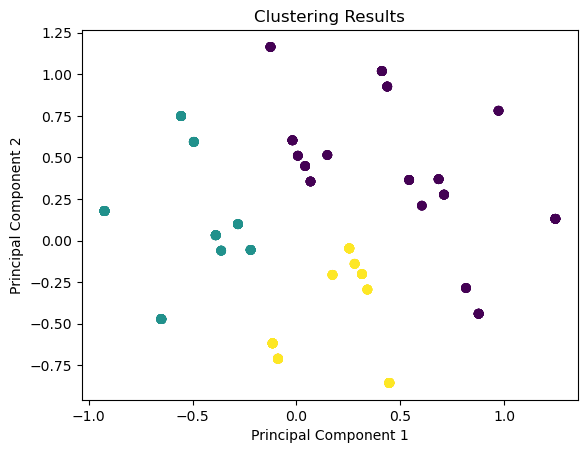

GMM - Silhouette Score: 0.3735970663032283
GMM - Davies-Bouldin Score: 0.9154942000401837


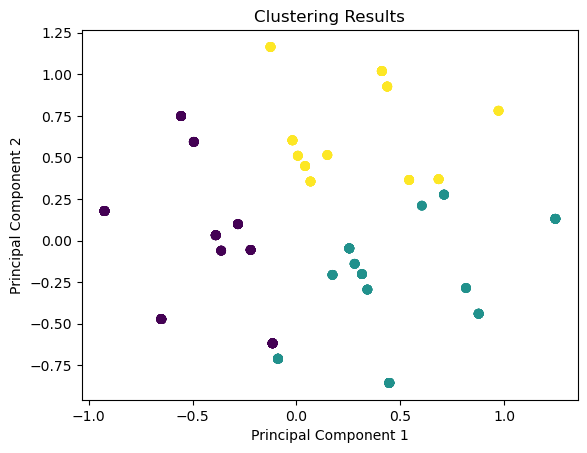

In [56]:
from sklearn.metrics import davies_bouldin_score

for model_name, model in models.items():
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(X.iloc[:, :-2])
    if model_name != 'GMM':
        labels = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, labels)
        db_score = davies_bouldin_score(data_pca, labels)  # Calculate Davies-Bouldin score
        print(f"{model_name} - Silhouette Score: {silhouette_avg}")
        print(f"{model_name} - Davies-Bouldin Score: {db_score}")
        visualize_clusters(data_pca, labels, len(np.unique(labels)))
    else:
        label = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, label)
        db_score = davies_bouldin_score(data_pca, label)  # Calculate Davies-Bouldin score
        print(f"{model_name} - Silhouette Score: {silhouette_avg}")
        print(f"{model_name} - Davies-Bouldin Score: {db_score}")
        visualize_clusters(data_pca, label, len(np.unique(label)))


### Evaluating the model performance with three different metrics

In [57]:
results = []

for model_name, model in models.items():
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(X.iloc[:, :-2])

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    if model_name != 'GMM':
        labels = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, labels)
        db_score = davies_bouldin_score(data_pca, labels)

        results.append({
            'Model': model_name,
            'Silhouette Score': silhouette_avg,
            'Davies-Bouldin Score': db_score,
            'Cumulative Explained Variance': cumulative_variance[-1]
        })
    else:
        label = model.fit_predict(data_pca)
        silhouette_avg = silhouette_score(data_pca, label)
        db_score = davies_bouldin_score(data_pca, label)

        results.append({
            'Model': model_name,
            'Silhouette Score': silhouette_avg,
            'Davies-Bouldin Score': db_score,
            'Cumulative Explained Variance': cumulative_variance[-1]
        })

df_results = pd.DataFrame(results)
df_results


,Model,Silhouette Score,Davies-Bouldin Score,Cumulative Explained Variance
0,K-means,0.440789,0.845382,0.51066
1,DBSCAN,0.885358,0.219916,0.51066
2,Agg. Hierarchical,0.404724,0.907511,0.51066
3,GMM,0.373597,0.915494,0.51066


Based on the provided evaluation metrics, the DBSCAN model performs the best among the tested models. It achieves a high silhouette score of 0.885 and a low Davies-Bouldin score of 0.219, indicating good cluster separation and compactness. Additionally, the cumulative explained variance is the same for all models, suggesting that dimensionality reduction does not significantly affect their performance.

---------------------
The silhouette score measures the quality of clustering by calculating the average distance between data points within clusters and the average distance between data points of different clusters. A higher silhouette score (ranging from -1 to 1) indicates better-defined clusters, with values closer to 1 indicating dense and well-separated clusters.

The Davies-Bouldin score evaluates the compactness and separation of clusters. A lower Davies-Bouldin score indicates better clustering, with values close to 0 indicating well-separated and compact clusters.

In the given output, the DBSCAN model achieves the highest silhouette score of 0.885, indicating that the clusters are well-defined and distinct. The Davies-Bouldin score of 0.219 also suggests good cluster separation and compactness. These scores indicate that the DBSCAN model performs well in capturing the underlying structure of the data and forming meaningful clusters.

It's worth noting that the cumulative explained variance is not directly related to the clustering performance. It represents the amount of variance in the data explained by the selected number of principal components in PCA. In this case, the cumulative explained variance is the same for all models, suggesting that dimensionality reduction does not significantly impact the clustering performance of these models.

### Aplying t-SNE to futher visualize the clustering

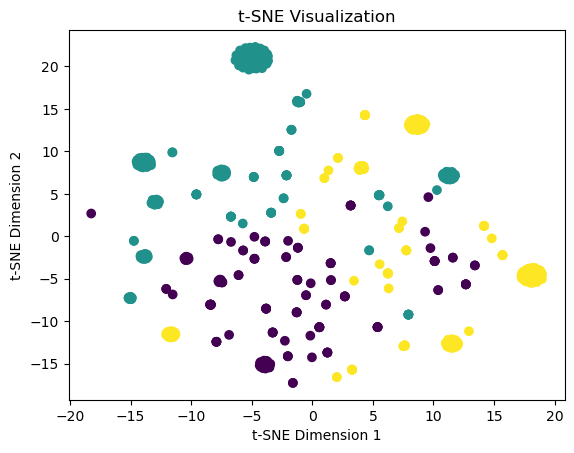

In [58]:
from sklearn.manifold import TSNE

# Apply t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(X)

# Visualize the t-SNE results
plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=labels, cmap='viridis')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization')
plt.show()


# Inference / Prediction

In [59]:
dbscan = DBSCAN(eps=0.3, min_samples=5)

In [60]:
import pandas as pd

def create_cluster_assignment_df(new_data, kmeans_labels, dbscan_labels):
    cluster_data = []
    
    # Iterate over each data point and store its corresponding cluster assignment
    for i, data_point in enumerate(new_data.values):
        student_name = data.iloc[i]["Gender"]
        kmeans_cluster = kmeans_labels[i]
        dbscan_cluster = dbscan_labels[i]
        
        cluster_data.append([student_name, kmeans_cluster, dbscan_cluster])
    
    # Create a DataFrame from the cluster assignment data
    df = pd.DataFrame(cluster_data, columns=['Student', 'K-means Cluster', 'DBSCAN Cluster'])
    
    return df

# # Assuming you have the new data stored in the 'new_data' variable

# # Predict clusters for the new data using the trained models
kmeans_labels = kmeans.predict(data_pca)
dbscan_labels = dbscan.fit_predict(data_pca)


# Create the cluster assignment DataFrame
cluster_assignment_df = create_cluster_assignment_df(data, kmeans_labels, dbscan_labels)

# Print the DataFrame
cluster_assignment_df


,Student,K-means Cluster,DBSCAN Cluster
0,F,2,0
1,M,1,1
2,F,0,2
3,M,1,3
4,M,0,4
...,...,...,...
444,M,0,8
445,M,1,11
446,M,0,12
447,F,2,10
